<a href="https://colab.research.google.com/github/juborduchi/cargos-diplomacia/blob/main/2_versao_analise_cargos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importação de Programas

In [ ]:
import json
import os
import numpy as np
import pandas as pd
import plotly.express as px
#!pip install pandas openpyxl
#!pip install dataframe-image
#!pip install -U kaleido

## Acesso ao Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [ ]:
caminho_padrao = "/content/gdrive/MyDrive" # comum a todos os usuários
caminho_especifico = "/Colab_Notebooks/unificada/" #caminho especifico de cada usuário
nome_arquivo = "lista-de-diplomatas-de-2015-a-2023-por-cargo-nome-e-gênero-SIC-201924.json"
caminho_pasta_arquivos = caminho_padrao + caminho_especifico
caminho_completo = caminho_padrao + caminho_especifico + nome_arquivo

## Converter tabela em arquivo JSON

In [ ]:
""" import pandas as pd

# Ler o arquivo Excel
df = pd.read_excel("lista-de-diplomatas-de-2015-a-2023-por-cargo-nome-e-gênero-SIC-201924.xlsx")

# Converter a coluna de data para datetime, se necessário
df["Ano"] = pd.to_datetime(df["Ano"], errors="coerce")

# Extrair apenas o ano
df["Ano"] = df["Ano"].dt.year

# Exportar para JSON
df.to_json("lista-de-diplomatas-de-2015-a-2023-por-cargo-nome-e-gênero-SIC-201924.json", orient="records", date_format="iso")

print("Arquivo JSON criado com sucesso!") """

' import pandas as pd\n\n# Ler o arquivo Excel\ndf = pd.read_excel("lista-de-diplomatas-de-2015-a-2023-por-cargo-nome-e-gênero-SIC-201924.xlsx")\n\n# Converter a coluna de data para datetime, se necessário\ndf["Ano"] = pd.to_datetime(df["Ano"], errors="coerce")\n\n# Extrair apenas o ano\ndf["Ano"] = df["Ano"].dt.year\n\n# Exportar para JSON\ndf.to_json("lista-de-diplomatas-de-2015-a-2023-por-cargo-nome-e-gênero-SIC-201924.json", orient="records", date_format="iso")\n\nprint("Arquivo JSON criado com sucesso!") '

In [ ]:
df = pd.read_json(caminho_completo, orient="columns")
df.shape

(12791, 4)

In [ ]:
df.columns
df

,Cargo,Servidor,Sexo,Ano
0,Conselheiro,Adriana Rodrigues Martins,FEM,2015.0
1,Conselheiro,Alessandra Claudio Vinhas,FEM,2015.0
2,Conselheiro,Ana Claudia de Faria Rodrigues,FEM,2015.0
3,Conselheiro,Ana Luiza Membrive Martins,FEM,2015.0
4,Conselheiro,Ana Patrícia Neves Tanaka Abdul-Hak,FEM,2015.0
...,...,...,...,...
12786,Terceiro Secretário,Fernando Simões dos Santos,MASC,2023.0
12787,Terceiro Secretário,Pedro Mahin Araujo Trindade,MASC,2023.0
12788,Terceiro Secretário,Emanuel Montenegro Batista Lins,MASC,2023.0
12789,Terceiro Secretário,João Paulo de Sousa Vieira,MASC,2023.0


In [ ]:
df_customizado = df[["Cargo"]]
df_customizado

,Cargo
0,Conselheiro
1,Conselheiro
2,Conselheiro
3,Conselheiro
4,Conselheiro
...,...
12786,Terceiro Secretário
12787,Terceiro Secretário
12788,Terceiro Secretário
12789,Terceiro Secretário


In [ ]:
df.dtypes

,0
Cargo,object
Servidor,object
Sexo,object
Ano,float64


## Análise 2015

### Mulheres 2015

In [ ]:
cont_ano_1_fem = df_customizado[(df["Ano"] == 2015) & (df["Sexo"] == "FEM")].value_counts()
cont_ano_1_fem

,count
Cargo,
Terceiro Secretário,75
Primeiro Secretário,58
Segundo Secretário,57
Conselheiro,39
Ministro de Segunda Classe,30
Ministro de Primeira Classe,16
Ministro de Segunda Classe do Quadro Especial,9
Conselheiro do Quadro Especial,6
Ministro de Primeira Classe do Quadro Especial,1


In [ ]:
ano_1_fem = df_customizado[(df["Ano"] == 2015) & (df["Sexo"] == "FEM")]
ano_1_fem

,Cargo
0,Conselheiro
1,Conselheiro
2,Conselheiro
3,Conselheiro
4,Conselheiro
...,...
1071,Terceiro Secretário
1072,Terceiro Secretário
1073,Terceiro Secretário
1074,Terceiro Secretário


In [ ]:
from collections import Counter
cargo_termos = ["Terceiro Secretário", "Primeiro Secretário", "Segundo Secretário", "Conselheiro", "Ministro de Segunda Classe", "Ministro de Primeira Classe"]

def contar_cargos(cargo,cargo_termos):

  contador = Counter()
  for palavra in cargo_termos:
    contador[palavra] = (cargo.lower() == (palavra.lower()))
  return contador

## aplicar/chamar a função contar_palavras a coluna de paragrafos e somar as ocorrências
## [lista_paragrafo01, lista_paragrafo02, lista_paragrafo03]
frequencias_ano_1_fem = Counter()
for cargo in ano_1_fem['Cargo']:
  frequencias_ano_1_fem += contar_cargos(cargo,cargo_termos) ## chamando a função contar_palavras e tendo como retorno a contagem dos termos listados

frequencias_ano_1_fem

Counter({'Conselheiro': 39,
         'Ministro de Primeira Classe': 16,
         'Ministro de Segunda Classe': 30,
         'Primeiro Secretário': 58,
         'Segundo Secretário': 57,
         'Terceiro Secretário': 75})

In [ ]:
from collections import Counter
cargo_termos_especial = ["Conselheiro do Quadro Especial", "Ministro de Primeira Classe do Quadro Especial", "Ministro de Segunda Classe do Quadro Especial"]

def contar_cargos(cargo,cargo_termos_especial):

  contador = Counter()
  for palavra in cargo_termos_especial:
    contador[palavra] = (cargo.lower() == (palavra.lower()))
  return contador

## aplicar/chamar a função contar_palavras a coluna de paragrafos e somar as ocorrências
## [lista_paragrafo01, lista_paragrafo02, lista_paragrafo03]
frequencias_ano_1_fem_especial = Counter()
for cargo in ano_1_fem['Cargo']:
  frequencias_ano_1_fem_especial += contar_cargos(cargo,cargo_termos_especial) ## chamando a função contar_palavras e tendo como retorno a contagem dos termos listados

frequencias_ano_1_fem_especial

Counter({'Conselheiro do Quadro Especial': 6,
         'Ministro de Primeira Classe do Quadro Especial': 1,
         'Ministro de Segunda Classe do Quadro Especial': 9})

In [ ]:
a = cont_ano_1_fem.keys()
a

MultiIndex([(                           'Terceiro Secretário',),
            (                           'Primeiro Secretário',),
            (                            'Segundo Secretário',),
            (                                   'Conselheiro',),
            (                    'Ministro de Segunda Classe',),
            (                   'Ministro de Primeira Classe',),
            ( 'Ministro de Segunda Classe do Quadro Especial',),
            (                'Conselheiro do Quadro Especial',),
            ('Ministro de Primeira Classe do Quadro Especial',)],
           names=['Cargo'])

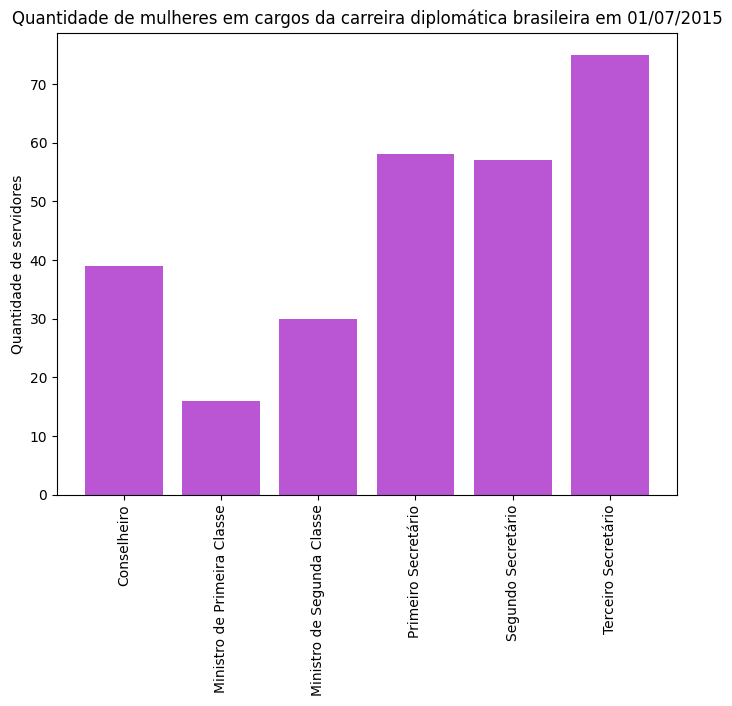

In [ ]:
import matplotlib.pyplot as plt

a = frequencias_ano_1_fem.keys()
b = frequencias_ano_1_fem.values()

plt.figure(figsize=(8,6))
plt.bar(a,b, color="#BA55D3")
plt.ylabel("Quantidade de servidores")
plt.title("Quantidade de mulheres em cargos da carreira diplomática brasileira em 01/07/2015")
plt.xticks(rotation=90)
plt.show()

### Homens 2015

In [ ]:
cont_ano_1_masc = df_customizado[(df["Ano"] == 2015) & (df["Sexo"] == "MASC")].value_counts()
cont_ano_1_masc

,count
Cargo,
Terceiro Secretário,232
Primeiro Secretário,185
Segundo Secretário,176
Conselheiro,171
Ministro de Segunda Classe,126
Ministro de Primeira Classe,81
Conselheiro do Quadro Especial,21
Ministro de Segunda Classe do Quadro Especial,21
Ministro de Primeira Classe do Quadro Especial,4


In [ ]:
ano_1_masc = df_customizado[(df["Ano"] == 2015) & (df["Sexo"] == "MASC")]
ano_1_masc

,Cargo
39,Conselheiro
40,Conselheiro
41,Conselheiro
42,Conselheiro
43,Conselheiro
...,...
1303,Terceiro Secretário
1304,Terceiro Secretário
1305,Terceiro Secretário
1306,Terceiro Secretário


In [ ]:
from collections import Counter
cargo_termos = ["Terceiro Secretário", "Primeiro Secretário", "Segundo Secretário", "Conselheiro", "Ministro de Segunda Classe", "Ministro de Primeira Classe"]

def contar_cargos(cargo,cargo_termos):

  contador = Counter()
  for palavra in cargo_termos:
    contador[palavra] = (cargo.lower() == (palavra.lower()))
  return contador

## aplicar/chamar a função contar_palavras a coluna de paragrafos e somar as ocorrências
## [lista_paragrafo01, lista_paragrafo02, lista_paragrafo03]
frequencias_ano_1_masc = Counter()
for cargo in ano_1_masc['Cargo']:
  frequencias_ano_1_masc += contar_cargos(cargo,cargo_termos) ## chamando a função contar_palavras e tendo como retorno a contagem dos termos listados

frequencias_ano_1_masc

Counter({'Conselheiro': 171,
         'Ministro de Primeira Classe': 81,
         'Ministro de Segunda Classe': 126,
         'Primeiro Secretário': 185,
         'Segundo Secretário': 176,
         'Terceiro Secretário': 232})

In [ ]:
from collections import Counter
cargo_termos_especial = ["Conselheiro do Quadro Especial", "Ministro de Primeira Classe do Quadro Especial", "Ministro de Segunda Classe do Quadro Especial"]

def contar_cargos(cargo,cargo_termos_especial):

  contador = Counter()
  for palavra in cargo_termos_especial:
    contador[palavra] = (cargo.lower() == (palavra.lower()))
  return contador

## aplicar/chamar a função contar_palavras a coluna de paragrafos e somar as ocorrências
## [lista_paragrafo01, lista_paragrafo02, lista_paragrafo03]
frequencias_ano_1_masc_especial = Counter()
for cargo in ano_1_masc['Cargo']:
  frequencias_ano_1_masc_especial += contar_cargos(cargo,cargo_termos_especial) ## chamando a função contar_palavras e tendo como retorno a contagem dos termos listados

frequencias_ano_1_masc_especial

Counter({'Conselheiro do Quadro Especial': 21,
         'Ministro de Primeira Classe do Quadro Especial': 4,
         'Ministro de Segunda Classe do Quadro Especial': 21})

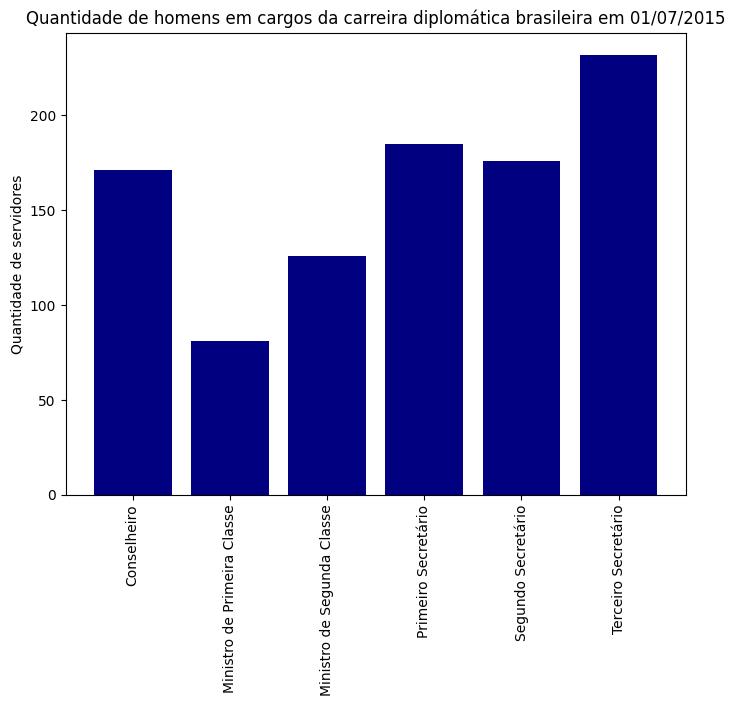

In [ ]:
import matplotlib.pyplot as plt

a = frequencias_ano_1_masc.keys()
b = frequencias_ano_1_masc.values()

plt.figure(figsize=(8,6))
plt.bar(a,b, color="#000080")
plt.ylabel("Quantidade de servidores")
plt.title("Quantidade de homens em cargos da carreira diplomática brasileira em 01/07/2015")
plt.xticks(rotation=90)
plt.show()

## Análise 2016

### Mulheres 2016

In [ ]:
cont_ano_2_fem = df_customizado[(df["Ano"] == 2016) & (df["Sexo"] == "FEM")].value_counts()
cont_ano_2_fem

,count
Cargo,
Terceiro Secretário,66
Primeiro Secretário,64
Segundo Secretário,64
Conselheiro,37
Ministro de Segunda Classe,30
Ministro de Primeira Classe,19
Ministro de Segunda Classe do Quadro Especial,9
Conselheiro do Quadro Especial,8
Ministro de Primeira Classe do Quadro Especial,1


In [ ]:
ano_2_fem = df_customizado[(df["Ano"] == 2016) & (df["Sexo"] == "FEM")]
ano_2_fem

,Cargo
1308,Conselheiro
1309,Conselheiro
1310,Conselheiro
1311,Conselheiro
1312,Conselheiro
...,...
2449,Terceiro Secretário
2450,Terceiro Secretário
2451,Terceiro Secretário
2452,Terceiro Secretário


In [ ]:
from collections import Counter
cargo_termos = ["Terceiro Secretário", "Primeiro Secretário", "Segundo Secretário", "Conselheiro", "Ministro de Segunda Classe", "Ministro de Primeira Classe"]

def contar_cargos(cargo,cargo_termos):

  contador = Counter()
  for palavra in cargo_termos:
    contador[palavra] = (cargo.lower() == (palavra.lower()))
  return contador

## aplicar/chamar a função contar_palavras a coluna de paragrafos e somar as ocorrências
## [lista_paragrafo01, lista_paragrafo02, lista_paragrafo03]
frequencias_ano_2_fem = Counter()
for cargo in ano_2_fem['Cargo']:
  frequencias_ano_2_fem += contar_cargos(cargo,cargo_termos) ## chamando a função contar_palavras e tendo como retorno a contagem dos termos listados

frequencias_ano_2_fem

Counter({'Conselheiro': 37,
         'Ministro de Primeira Classe': 19,
         'Ministro de Segunda Classe': 30,
         'Primeiro Secretário': 64,
         'Segundo Secretário': 64,
         'Terceiro Secretário': 66})

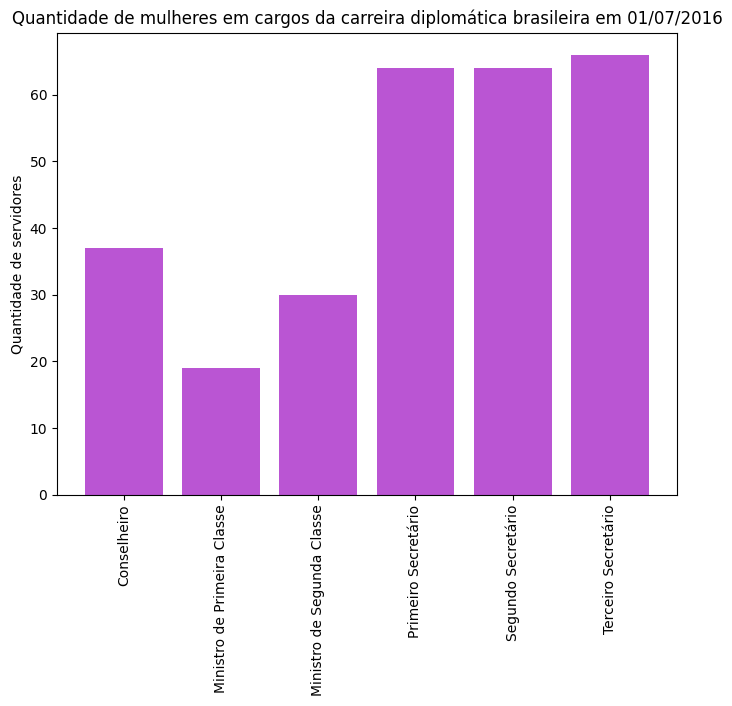

In [ ]:
import matplotlib.pyplot as plt

a = frequencias_ano_2_fem.keys()
b = frequencias_ano_2_fem.values()

plt.figure(figsize=(8,6))
plt.bar(a,b, color="#BA55D3")
plt.ylabel("Quantidade de servidores")
plt.title("Quantidade de mulheres em cargos da carreira diplomática brasileira em 01/07/2016")
plt.xticks(rotation=90)
plt.show()

### Homens 2016

In [ ]:
cont_ano_2_masc = df_customizado[(df["Ano"] == 2016) & (df["Sexo"] == "MASC")].value_counts()
cont_ano_2_masc

,count
Cargo,
Segundo Secretário,209
Terceiro Secretário,196
Primeiro Secretário,194
Conselheiro,175
Ministro de Segunda Classe,126
Ministro de Primeira Classe,87
Conselheiro do Quadro Especial,27
Ministro de Segunda Classe do Quadro Especial,23
Ministro de Primeira Classe do Quadro Especial,5


In [ ]:
ano_2_masc = df_customizado[(df["Ano"] == 2016) & (df["Sexo"] == "MASC")]
ano_2_masc

,Cargo
1345,Conselheiro
1346,Conselheiro
1347,Conselheiro
1348,Conselheiro
1349,Conselheiro
...,...
2645,Terceiro Secretário
2646,Terceiro Secretário
2647,Terceiro Secretário
2648,Terceiro Secretário


In [ ]:
from collections import Counter
cargo_termos = ["Terceiro Secretário", "Primeiro Secretário", "Segundo Secretário", "Conselheiro", "Ministro de Segunda Classe", "Ministro de Primeira Classe"]

def contar_cargos(cargo,cargo_termos):

  contador = Counter()
  for palavra in cargo_termos:
    contador[palavra] = (cargo.lower() == (palavra.lower()))
  return contador

## aplicar/chamar a função contar_palavras a coluna de paragrafos e somar as ocorrências
## [lista_paragrafo01, lista_paragrafo02, lista_paragrafo03]
frequencias_ano_2_masc = Counter()
for cargo in ano_2_masc['Cargo']:
  frequencias_ano_2_masc += contar_cargos(cargo,cargo_termos) ## chamando a função contar_palavras e tendo como retorno a contagem dos termos listados

frequencias_ano_2_masc

Counter({'Conselheiro': 175,
         'Ministro de Primeira Classe': 87,
         'Ministro de Segunda Classe': 126,
         'Primeiro Secretário': 194,
         'Segundo Secretário': 209,
         'Terceiro Secretário': 196})

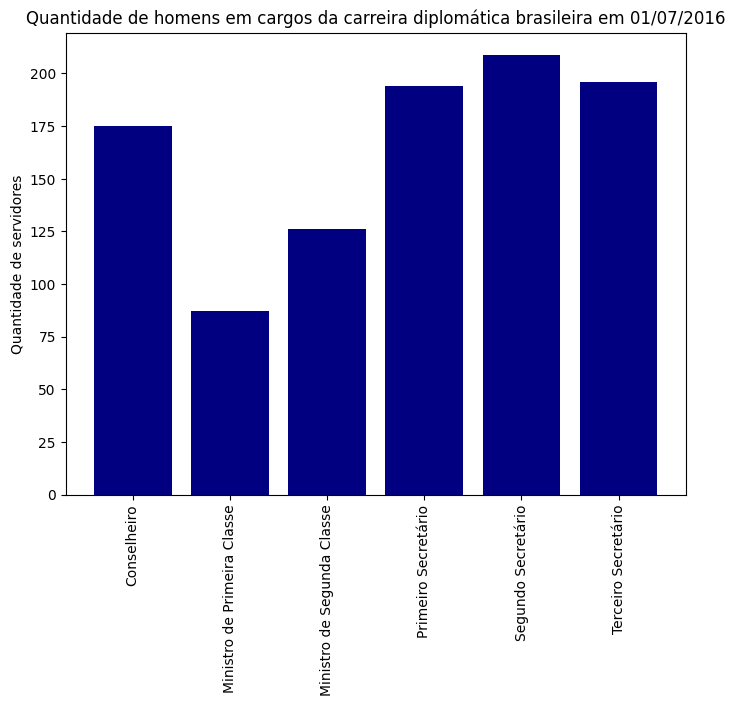

In [ ]:

import matplotlib.pyplot as plt

a = frequencias_ano_2_masc.keys()
b = frequencias_ano_2_masc.values()

plt.figure(figsize=(8,6))
plt.bar(a,b, color="#000080")
plt.ylabel("Quantidade de servidores")
plt.title("Quantidade de homens em cargos da carreira diplomática brasileira em 01/07/2016")
plt.xticks(rotation=90)
plt.show()

## Análise 2017

### Mulheres 2017

In [ ]:
cont_ano_3_fem = df_customizado[(df["Ano"] == 2017) & (df["Sexo"] == "FEM")].value_counts()
cont_ano_3_fem


,count
Cargo,
Segundo Secretário,78
Primeiro Secretário,65
Terceiro Secretário,54
Conselheiro,39
Ministro de Segunda Classe,31
Ministro de Primeira Classe,19
Ministro de Segunda Classe do Quadro Especial,10
Conselheiro do Quadro Especial,9
Ministro de Primeira Classe do Quadro Especial,3


In [ ]:
ano_3_fem = df_customizado[(df["Ano"] == 2017) & (df["Sexo"] == "FEM")]
ano_3_fem

,Cargo
2650,Conselheiro
2651,Conselheiro
2652,Conselheiro
2653,Conselheiro
2654,Conselheiro
...,...
3859,Terceiro Secretário
3860,Terceiro Secretário
3861,Terceiro Secretário
3862,Terceiro Secretário


In [ ]:
from collections import Counter
cargo_termos = ["Terceiro Secretário", "Primeiro Secretário", "Segundo Secretário", "Conselheiro", "Ministro de Segunda Classe", "Ministro de Primeira Classe"]

def contar_cargos(cargo,cargo_termos):

  contador = Counter()
  for palavra in cargo_termos:
    contador[palavra] = (cargo.lower() == (palavra.lower()))
  return contador

## aplicar/chamar a função contar_palavras a coluna de paragrafos e somar as ocorrências
## [lista_paragrafo01, lista_paragrafo02, lista_paragrafo03]
frequencias_ano_3_fem = Counter()
for cargo in ano_3_fem['Cargo']:
  frequencias_ano_3_fem += contar_cargos(cargo,cargo_termos) ## chamando a função contar_palavras e tendo como retorno a contagem dos termos listados

frequencias_ano_3_fem

Counter({'Conselheiro': 39,
         'Ministro de Primeira Classe': 19,
         'Ministro de Segunda Classe': 31,
         'Primeiro Secretário': 65,
         'Segundo Secretário': 78,
         'Terceiro Secretário': 54})

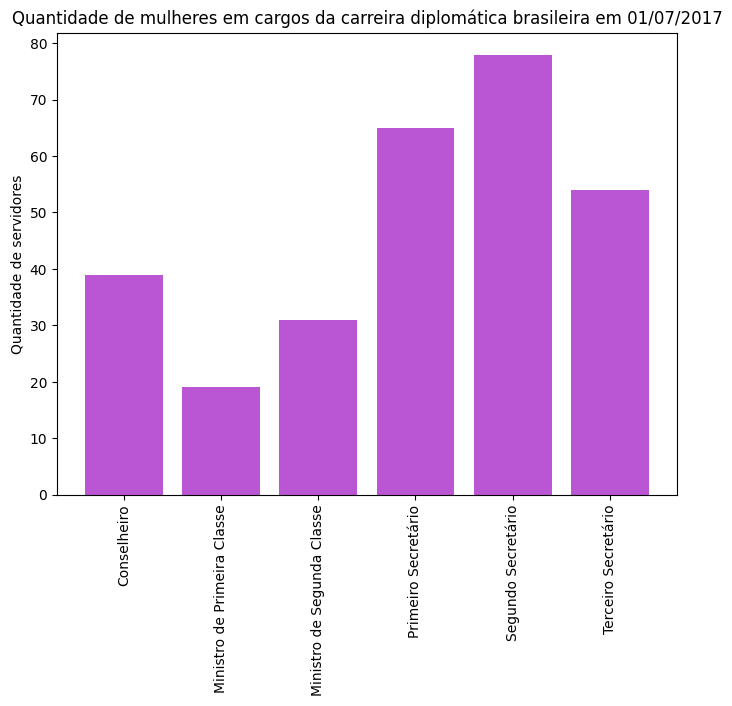

In [ ]:
import matplotlib.pyplot as plt

a = frequencias_ano_3_fem.keys()
b = frequencias_ano_3_fem.values()

plt.figure(figsize=(8,6))
plt.bar(a,b, color="#BA55D3")
plt.ylabel("Quantidade de servidores")
plt.title("Quantidade de mulheres em cargos da carreira diplomática brasileira em 01/07/2017")
plt.xticks(rotation=90)
plt.show()

### Homens 2017

In [ ]:
cont_ano_3_masc = df_customizado[(df["Ano"] == 2017) & (df["Sexo"] == "MASC")].value_counts()
cont_ano_3_masc

,count
Cargo,
Segundo Secretário,231
Primeiro Secretário,200
Conselheiro,176
Terceiro Secretário,162
Ministro de Segunda Classe,133
Ministro de Primeira Classe,90
Conselheiro do Quadro Especial,34
Ministro de Segunda Classe do Quadro Especial,26
Ministro de Primeira Classe do Quadro Especial,14


In [ ]:
ano_3_masc = df_customizado[(df["Ano"] == 2017) & (df["Sexo"] == "MASC")]
ano_3_masc

,Cargo
2689,Conselheiro
2690,Conselheiro
2691,Conselheiro
2692,Conselheiro
2693,Conselheiro
...,...
4021,Terceiro Secretário
4022,Terceiro Secretário
4023,Terceiro Secretário
4024,Terceiro Secretário


In [ ]:
from collections import Counter
cargo_termos = ["Terceiro Secretário", "Primeiro Secretário", "Segundo Secretário", "Conselheiro", "Ministro de Segunda Classe", "Ministro de Primeira Classe"]

def contar_cargos(cargo,cargo_termos):

  contador = Counter()
  for palavra in cargo_termos:
    contador[palavra] = (cargo.lower() == (palavra.lower()))
  return contador

## aplicar/chamar a função contar_palavras a coluna de paragrafos e somar as ocorrências
## [lista_paragrafo01, lista_paragrafo02, lista_paragrafo03]
frequencias_ano_3_masc = Counter()
for cargo in ano_3_masc['Cargo']:
  frequencias_ano_3_masc += contar_cargos(cargo,cargo_termos) ## chamando a função contar_palavras e tendo como retorno a contagem dos termos listados

frequencias_ano_3_masc

Counter({'Conselheiro': 176,
         'Ministro de Primeira Classe': 90,
         'Ministro de Segunda Classe': 133,
         'Primeiro Secretário': 200,
         'Segundo Secretário': 231,
         'Terceiro Secretário': 162})

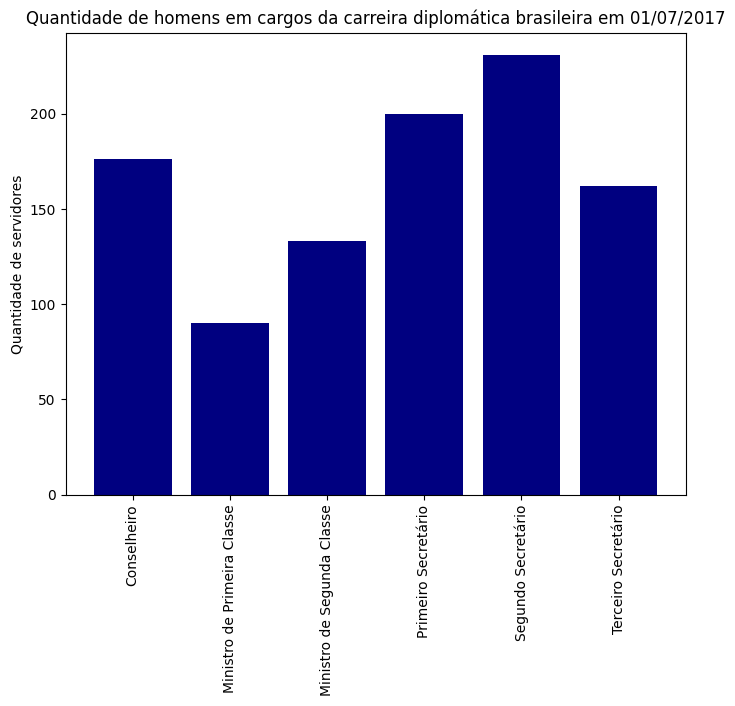

In [ ]:

import matplotlib.pyplot as plt

a = frequencias_ano_3_masc.keys()
b = frequencias_ano_3_masc.values()

plt.figure(figsize=(8,6))
plt.bar(a,b, color="#000080" )
plt.ylabel("Quantidade de servidores")
plt.title("Quantidade de homens em cargos da carreira diplomática brasileira em 01/07/2017")
plt.xticks(rotation=90)
plt.show()

## Análise 2018

### Mulheres 2018

In [ ]:
cont_ano_4_fem = df_customizado[(df["Ano"] == 2018) & (df["Sexo"] == "FEM")].value_counts()
cont_ano_4_fem


,count
Cargo,
Segundo Secretário,77
Primeiro Secretário,71
Terceiro Secretário,53
Conselheiro,44
Ministro de Segunda Classe,32
Ministro de Primeira Classe,19
Ministro de Segunda Classe do Quadro Especial,11
Conselheiro do Quadro Especial,9
Ministro de Primeira Classe do Quadro Especial,5


In [ ]:
ano_4_fem = df_customizado[(df["Ano"] == 2018) & (df["Sexo"] == "FEM")]
ano_4_fem

,Cargo
4026,Conselheiro
4027,Conselheiro
4028,Conselheiro
4029,Conselheiro
4030,Conselheiro
...,...
5300,Terceiro Secretário
5301,Terceiro Secretário
5302,Terceiro Secretário
5303,Terceiro Secretário


In [ ]:
from collections import Counter
cargo_termos = ["Terceiro Secretário", "Primeiro Secretário", "Segundo Secretário", "Conselheiro", "Ministro de Segunda Classe", "Ministro de Primeira Classe"]

def contar_cargos(cargo,cargo_termos):

  contador = Counter()
  for palavra in cargo_termos:
    contador[palavra] = (cargo.lower() == (palavra.lower()))
  return contador

## aplicar/chamar a função contar_palavras a coluna de paragrafos e somar as ocorrências
## [lista_paragrafo01, lista_paragrafo02, lista_paragrafo03]
frequencias_ano_4_fem = Counter()
for cargo in ano_4_fem['Cargo']:
  frequencias_ano_4_fem += contar_cargos(cargo,cargo_termos) ## chamando a função contar_palavras e tendo como retorno a contagem dos termos listados

frequencias_ano_4_fem

Counter({'Conselheiro': 44,
         'Ministro de Primeira Classe': 19,
         'Ministro de Segunda Classe': 32,
         'Primeiro Secretário': 71,
         'Segundo Secretário': 77,
         'Terceiro Secretário': 53})

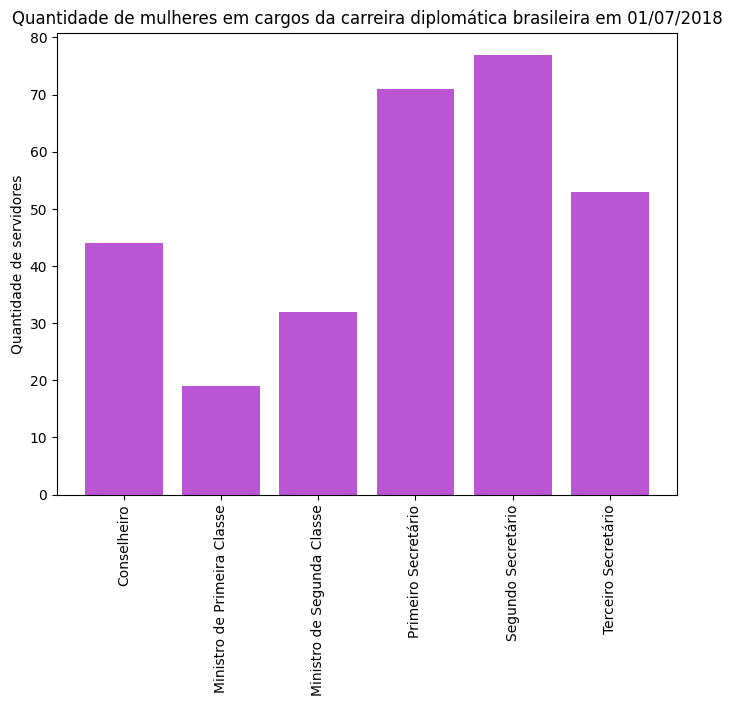

In [ ]:
import matplotlib.pyplot as plt

a = frequencias_ano_4_fem.keys()
b = frequencias_ano_4_fem.values()

plt.figure(figsize=(8,6))
plt.bar(a,b, color="#BA55D3")
plt.ylabel("Quantidade de servidores")
plt.title("Quantidade de mulheres em cargos da carreira diplomática brasileira em 01/07/2018")
plt.xticks(rotation=90)
plt.show()

### Homens 2018

In [ ]:
cont_ano_4_masc = df_customizado[(df["Ano"] == 2018) & (df["Sexo"] == "MASC")].value_counts()
cont_ano_4_masc

,count
Cargo,
Segundo Secretário,255
Primeiro Secretário,209
Conselheiro,174
Ministro de Segunda Classe,132
Terceiro Secretário,127
Ministro de Primeira Classe,92
Conselheiro do Quadro Especial,35
Ministro de Segunda Classe do Quadro Especial,33
Ministro de Primeira Classe do Quadro Especial,26


In [ ]:
ano_4_masc = df_customizado[(df["Ano"] == 2018) & (df["Sexo"] == "MASC")]
ano_4_masc

,Cargo
4070,Conselheiro
4071,Conselheiro
4072,Conselheiro
4073,Conselheiro
4074,Conselheiro
...,...
5427,Terceiro Secretário
5428,Terceiro Secretário
5429,Terceiro Secretário
5430,Terceiro Secretário


In [ ]:
from collections import Counter
cargo_termos = ["Terceiro Secretário", "Primeiro Secretário", "Segundo Secretário", "Conselheiro", "Ministro de Segunda Classe", "Ministro de Primeira Classe"]

def contar_cargos(cargo,cargo_termos):

  contador = Counter()
  for palavra in cargo_termos:
    contador[palavra] = (cargo.lower() == (palavra.lower()))
  return contador

## aplicar/chamar a função contar_palavras a coluna de paragrafos e somar as ocorrências
## [lista_paragrafo01, lista_paragrafo02, lista_paragrafo03]
frequencias_ano_4_masc = Counter()
for cargo in ano_4_masc['Cargo']:
  frequencias_ano_4_masc += contar_cargos(cargo,cargo_termos) ## chamando a função contar_palavras e tendo como retorno a contagem dos termos listados

frequencias_ano_4_masc

Counter({'Conselheiro': 174,
         'Ministro de Primeira Classe': 92,
         'Ministro de Segunda Classe': 132,
         'Primeiro Secretário': 209,
         'Segundo Secretário': 255,
         'Terceiro Secretário': 127})

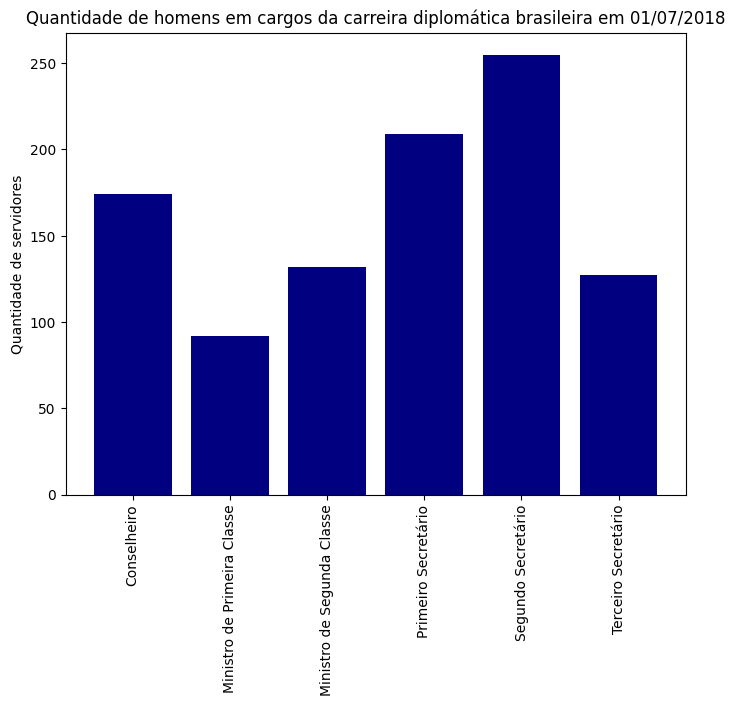

In [ ]:
import matplotlib.pyplot as plt

a = frequencias_ano_4_masc.keys()
b = frequencias_ano_4_masc.values()

plt.figure(figsize=(8,6))
plt.bar(a,b, color="#000080")
plt.ylabel("Quantidade de servidores")
plt.title("Quantidade de homens em cargos da carreira diplomática brasileira em 01/07/2018")
plt.xticks(rotation=90)
plt.show()

## Análise 2019

### Mulheres 2019

In [ ]:
cont_ano_5_fem = df_customizado[(df["Ano"] == 2019) & (df["Sexo"] == "FEM")].value_counts()
cont_ano_5_fem

,count
Cargo,
Segundo Secretário,81
Primeiro Secretário,72
Conselheiro,45
Terceiro Secretário,43
Ministro de Segunda Classe,36
Ministro de Primeira Classe,18
Conselheiro do Quadro Especial,10
Ministro de Segunda Classe do Quadro Especial,10
Ministro de Primeira Classe do Quadro Especial,9


In [ ]:
ano_5_fem = df_customizado[(df["Ano"] == 2019) & (df["Sexo"] == "FEM")]
ano_5_fem

,Cargo
5433,Conselheiro
5434,Conselheiro
5435,Conselheiro
5436,Conselheiro
5437,Conselheiro
...,...
6751,Terceiro Secretário
6752,Terceiro Secretário
6753,Terceiro Secretário
6754,Terceiro Secretário


In [ ]:
from collections import Counter
cargo_termos = ["Terceiro Secretário", "Primeiro Secretário", "Segundo Secretário", "Conselheiro", "Ministro de Segunda Classe", "Ministro de Primeira Classe"]

def contar_cargos(cargo,cargo_termos):

  contador = Counter()
  for palavra in cargo_termos:
    contador[palavra] = (cargo.lower() == (palavra.lower()))
  return contador

## aplicar/chamar a função contar_palavras a coluna de paragrafos e somar as ocorrências
## [lista_paragrafo01, lista_paragrafo02, lista_paragrafo03]
frequencias_ano_5_fem = Counter()
for cargo in ano_5_fem['Cargo']:
  frequencias_ano_5_fem += contar_cargos(cargo,cargo_termos) ## chamando a função contar_palavras e tendo como retorno a contagem dos termos listados

frequencias_ano_5_fem


Counter({'Conselheiro': 45,
         'Ministro de Primeira Classe': 18,
         'Ministro de Segunda Classe': 36,
         'Primeiro Secretário': 72,
         'Segundo Secretário': 81,
         'Terceiro Secretário': 43})

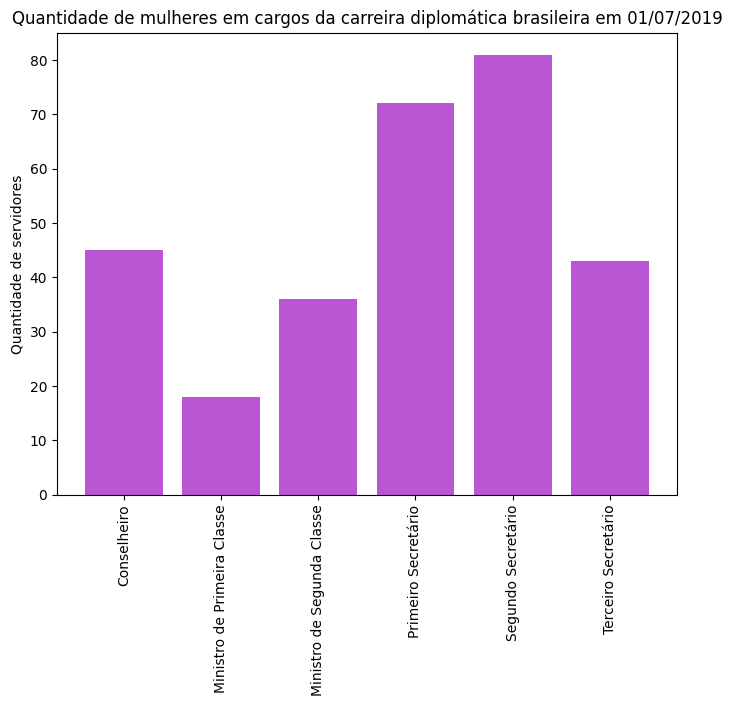

In [ ]:
import matplotlib.pyplot as plt

a = frequencias_ano_5_fem.keys()
b = frequencias_ano_5_fem.values()

plt.figure(figsize=(8,6))
plt.bar(a,b, color="#BA55D3")
plt.ylabel("Quantidade de servidores")
plt.title("Quantidade de mulheres em cargos da carreira diplomática brasileira em 01/07/2019")
plt.xticks(rotation=90)
plt.show()

### Homens 2019

In [ ]:
cont_ano_5_masc = df_customizado[(df["Ano"] == 2019) & (df["Sexo"] == "MASC")].value_counts()
cont_ano_5_masc

,count
Cargo,
Segundo Secretário,258
Primeiro Secretário,226
Conselheiro,174
Ministro de Segunda Classe,130
Terceiro Secretário,113
Ministro de Primeira Classe,99
Ministro de Segunda Classe do Quadro Especial,40
Conselheiro do Quadro Especial,39
Ministro de Primeira Classe do Quadro Especial,30


In [ ]:
ano_5_masc = df_customizado[(df["Ano"] == 2019) & (df["Sexo"] == "MASC")]
ano_5_masc

,Cargo
5478,Conselheiro
5479,Conselheiro
5480,Conselheiro
5481,Conselheiro
5482,Conselheiro
...,...
6864,Terceiro Secretário
6865,Terceiro Secretário
6866,Terceiro Secretário
6867,Terceiro Secretário


In [ ]:
from collections import Counter
cargo_termos = ["Terceiro Secretário", "Primeiro Secretário", "Segundo Secretário", "Conselheiro", "Ministro de Segunda Classe", "Ministro de Primeira Classe"]

def contar_cargos(cargo,cargo_termos):

  contador = Counter()
  for palavra in cargo_termos:
    contador[palavra] = (cargo.lower() == (palavra.lower()))
  return contador

## aplicar/chamar a função contar_palavras a coluna de paragrafos e somar as ocorrências
## [lista_paragrafo01, lista_paragrafo02, lista_paragrafo03]
frequencias_ano_5_masc = Counter()
for cargo in ano_5_masc['Cargo']:
  frequencias_ano_5_masc += contar_cargos(cargo,cargo_termos) ## chamando a função contar_palavras e tendo como retorno a contagem dos termos listados

frequencias_ano_5_masc

Counter({'Conselheiro': 174,
         'Ministro de Primeira Classe': 99,
         'Ministro de Segunda Classe': 130,
         'Primeiro Secretário': 226,
         'Segundo Secretário': 258,
         'Terceiro Secretário': 113})

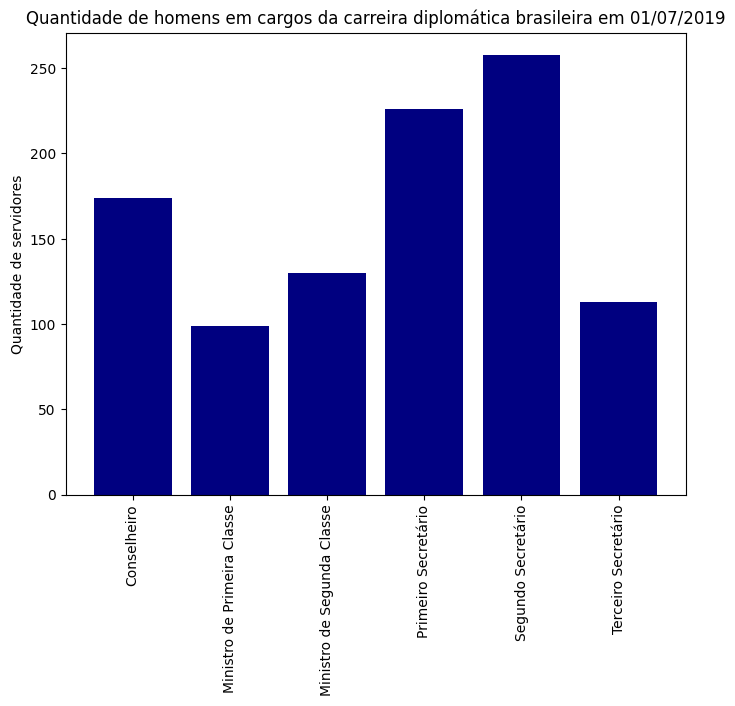

In [ ]:

import matplotlib.pyplot as plt

a = frequencias_ano_5_masc.keys()
b = frequencias_ano_5_masc.values()

plt.figure(figsize=(8,6))
plt.bar(a,b, color="#000080")
plt.ylabel("Quantidade de servidores")
plt.title("Quantidade de homens em cargos da carreira diplomática brasileira em 01/07/2019")
plt.xticks(rotation=90)
plt.show()

## Análise 2020

### Mulheres 2020

In [ ]:
cont_ano_6_fem = df_customizado[(df["Ano"] == 2020) & (df["Sexo"] == "FEM")].value_counts()
cont_ano_6_fem

,count
Cargo,
Segundo Secretário,85
Primeiro Secretário,75
Conselheiro,45
Terceiro Secretário,38
Ministro de Segunda Classe,34
Ministro de Primeira Classe,18
Conselheiro do Quadro Especial,12
Ministro de Primeira Classe do Quadro Especial,12
Ministro de Segunda Classe do Quadro Especial,10


In [ ]:
ano_6_fem = df_customizado[(df["Ano"] == 2020) & (df["Sexo"] == "FEM")]
ano_6_fem

,Cargo
6869,Conselheiro
6870,Conselheiro
6871,Conselheiro
6872,Conselheiro
6873,Conselheiro
...,...
8217,Terceiro Secretário
8218,Terceiro Secretário
8219,Terceiro Secretário
8220,Terceiro Secretário


In [ ]:
from collections import Counter
cargo_termos = ["Terceiro Secretário", "Primeiro Secretário", "Segundo Secretário", "Conselheiro", "Ministro de Segunda Classe", "Ministro de Primeira Classe"]

def contar_cargos(cargo,cargo_termos):

  contador = Counter()
  for palavra in cargo_termos:
    contador[palavra] = (cargo.lower() == (palavra.lower()))
  return contador

## aplicar/chamar a função contar_palavras a coluna de paragrafos e somar as ocorrências
## [lista_paragrafo01, lista_paragrafo02, lista_paragrafo03]
frequencias_ano_6_fem = Counter()
for cargo in ano_6_fem['Cargo']:
  frequencias_ano_6_fem += contar_cargos(cargo,cargo_termos) ## chamando a função contar_palavras e tendo como retorno a contagem dos termos listados

frequencias_ano_6_fem

Counter({'Conselheiro': 45,
         'Ministro de Primeira Classe': 18,
         'Ministro de Segunda Classe': 34,
         'Primeiro Secretário': 75,
         'Segundo Secretário': 85,
         'Terceiro Secretário': 38})

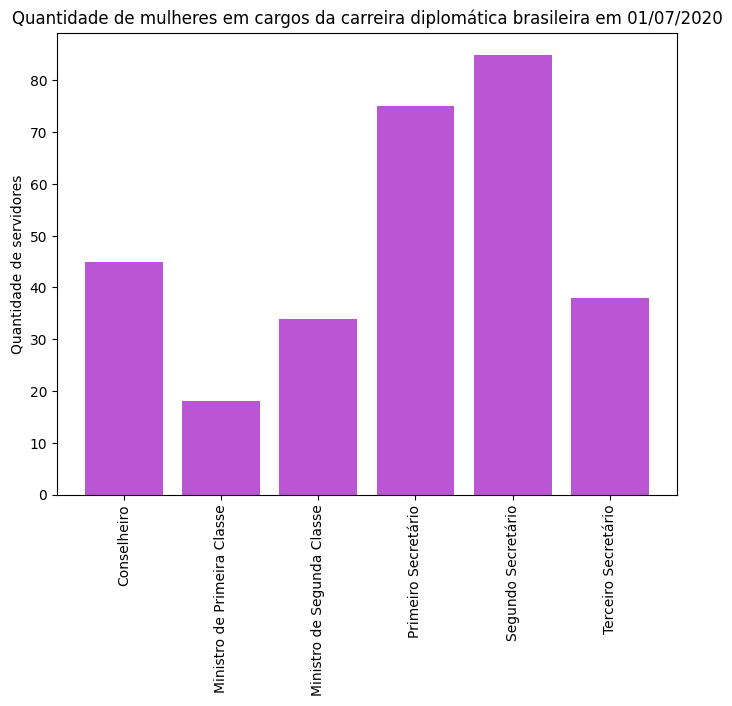

In [ ]:

import matplotlib.pyplot as plt

a = frequencias_ano_6_fem.keys()
b = frequencias_ano_6_fem.values()

plt.figure(figsize=(8,6))
plt.bar(a,b, color="#BA55D3")
plt.ylabel("Quantidade de servidores")
plt.title("Quantidade de mulheres em cargos da carreira diplomática brasileira em 01/07/2020")
plt.xticks(rotation=90)
plt.show()

### Homens 2020

In [ ]:
cont_ano_6_masc = df_customizado[(df["Ano"] == 2020) & (df["Sexo"] == "MASC")].value_counts()
cont_ano_6_masc


,count
Cargo,
Segundo Secretário,255
Primeiro Secretário,225
Conselheiro,177
Ministro de Segunda Classe,134
Terceiro Secretário,108
Ministro de Primeira Classe,103
Conselheiro do Quadro Especial,47
Ministro de Segunda Classe do Quadro Especial,44
Ministro de Primeira Classe do Quadro Especial,36


In [ ]:
ano_6_masc = df_customizado[(df["Ano"] == 2020) & (df["Sexo"] == "MASC")]
ano_6_masc

,Cargo
6914,Conselheiro
6915,Conselheiro
6916,Conselheiro
6917,Conselheiro
6918,Conselheiro
...,...
8325,Terceiro Secretário
8326,Terceiro Secretário
8327,Terceiro Secretário
8328,Terceiro Secretário


In [ ]:
from collections import Counter
cargo_termos = ["Terceiro Secretário", "Primeiro Secretário", "Segundo Secretário", "Conselheiro", "Ministro de Segunda Classe", "Ministro de Primeira Classe"]

def contar_cargos(cargo,cargo_termos):

  contador = Counter()
  for palavra in cargo_termos:
    contador[palavra] = (cargo.lower() == (palavra.lower()))
  return contador

## aplicar/chamar a função contar_palavras a coluna de paragrafos e somar as ocorrências
## [lista_paragrafo01, lista_paragrafo02, lista_paragrafo03]
frequencias_ano_6_masc = Counter()
for cargo in ano_6_masc['Cargo']:
  frequencias_ano_6_masc += contar_cargos(cargo,cargo_termos) ## chamando a função contar_palavras e tendo como retorno a contagem dos termos listados

frequencias_ano_6_masc


Counter({'Conselheiro': 177,
         'Ministro de Primeira Classe': 103,
         'Ministro de Segunda Classe': 134,
         'Primeiro Secretário': 225,
         'Segundo Secretário': 255,
         'Terceiro Secretário': 108})

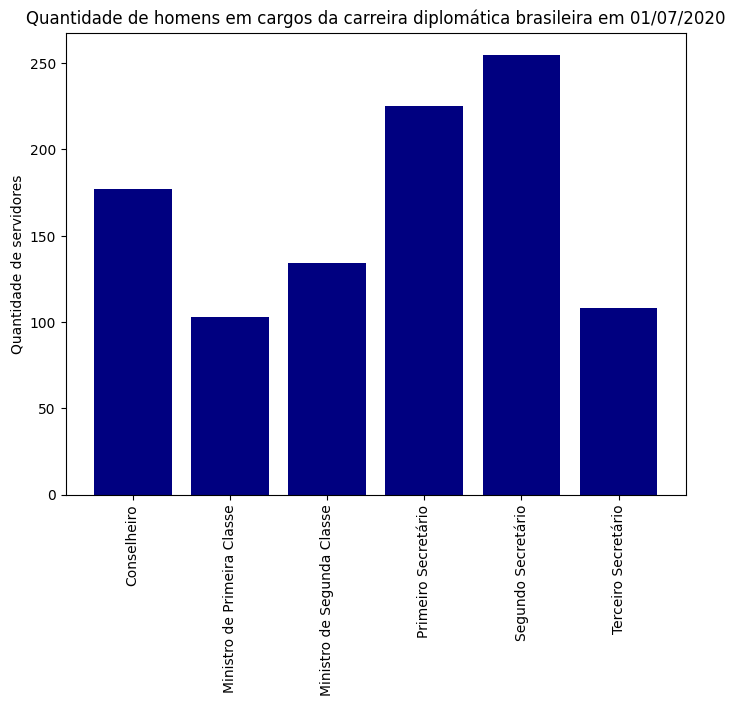

In [ ]:

import matplotlib.pyplot as plt

a = frequencias_ano_6_masc.keys()
b = frequencias_ano_6_masc.values()

plt.figure(figsize=(8,6))
plt.bar(a,b, color="#000080")
plt.ylabel("Quantidade de servidores")
plt.title("Quantidade de homens em cargos da carreira diplomática brasileira em 01/07/2020")
plt.xticks(rotation=90)
plt.show()

## Análise 2021

### Mulheres 2021

In [ ]:
cont_ano_7_fem = df_customizado[(df["Ano"] == 2021) & (df["Sexo"] == "FEM")].value_counts()
cont_ano_7_fem

,count
Cargo,
Segundo Secretário,85
Primeiro Secretário,79
Conselheiro,49
Ministro de Segunda Classe,34
Terceiro Secretário,23
Ministro de Primeira Classe,18
Conselheiro do Quadro Especial,15
Ministro de Primeira Classe do Quadro Especial,14
Ministro de Segunda Classe do Quadro Especial,9


In [ ]:
ano_7_fem = df_customizado[(df["Ano"] == 2021) & (df["Sexo"] == "FEM")]
ano_7_fem


,Cargo
8331,Conselheiro
8332,Conselheiro
8333,Conselheiro
8334,Conselheiro
8335,Conselheiro
...,...
9702,Terceiro Secretário
9703,Terceiro Secretário
9704,Terceiro Secretário
9705,Terceiro Secretário


In [ ]:
from collections import Counter
cargo_termos = ["Terceiro Secretário", "Primeiro Secretário", "Segundo Secretário", "Conselheiro", "Ministro de Segunda Classe", "Ministro de Primeira Classe"]

def contar_cargos(cargo,cargo_termos):

  contador = Counter()
  for palavra in cargo_termos:
    contador[palavra] = (cargo.lower() == (palavra.lower()))
  return contador

## aplicar/chamar a função contar_palavras a coluna de paragrafos e somar as ocorrências
## [lista_paragrafo01, lista_paragrafo02, lista_paragrafo03]
frequencias_ano_7_fem = Counter()
for cargo in ano_7_fem['Cargo']:
  frequencias_ano_7_fem += contar_cargos(cargo,cargo_termos) ## chamando a função contar_palavras e tendo como retorno a contagem dos termos listados

frequencias_ano_7_fem

Counter({'Conselheiro': 49,
         'Ministro de Primeira Classe': 18,
         'Ministro de Segunda Classe': 34,
         'Primeiro Secretário': 79,
         'Segundo Secretário': 85,
         'Terceiro Secretário': 23})

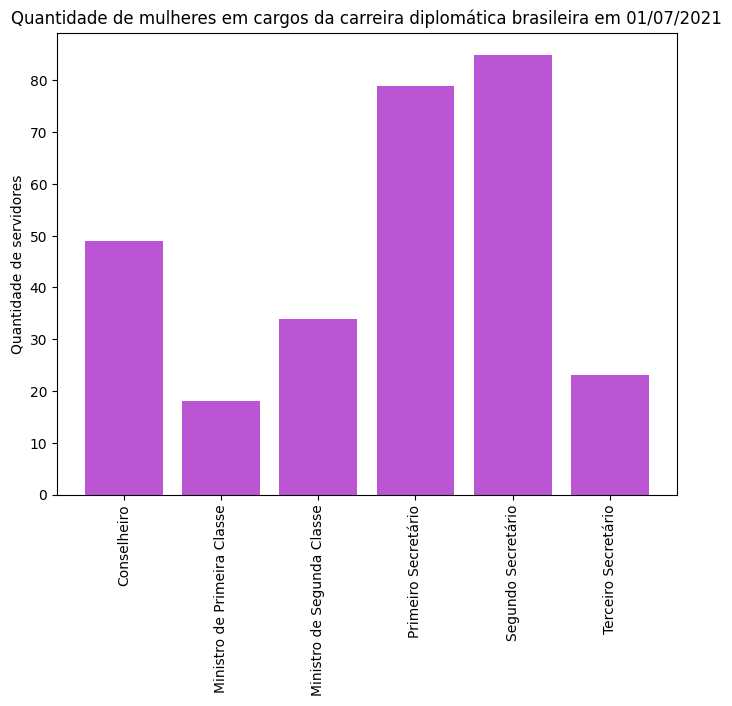

In [ ]:
import matplotlib.pyplot as plt

a = frequencias_ano_7_fem.keys()
b = frequencias_ano_7_fem.values()

plt.figure(figsize=(8,6))
plt.bar(a,b, color="#BA55D3")
plt.ylabel("Quantidade de servidores")
plt.title("Quantidade de mulheres em cargos da carreira diplomática brasileira em 01/07/2021")
plt.xticks(rotation=90)
plt.show()

### Homens 2021

In [ ]:
cont_ano_7_masc = df_customizado[(df["Ano"] == 2021) & (df["Sexo"] == "MASC")].value_counts()
cont_ano_7_masc


,count
Cargo,
Segundo Secretário,254
Primeiro Secretário,239
Conselheiro,174
Ministro de Segunda Classe,132
Ministro de Primeira Classe,105
Terceiro Secretário,76
Conselheiro do Quadro Especial,54
Ministro de Primeira Classe do Quadro Especial,46
Ministro de Segunda Classe do Quadro Especial,43


In [ ]:

ano_7_masc = df_customizado[(df["Ano"] == 2021) & (df["Sexo"] == "MASC")]
ano_7_masc

,Cargo
8380,Conselheiro
8381,Conselheiro
8382,Conselheiro
8383,Conselheiro
8384,Conselheiro
...,...
9778,Terceiro Secretário
9779,Terceiro Secretário
9780,Terceiro Secretário
9781,Terceiro Secretário


In [ ]:
from collections import Counter
cargo_termos = ["Terceiro Secretário", "Primeiro Secretário", "Segundo Secretário", "Conselheiro", "Ministro de Segunda Classe", "Ministro de Primeira Classe"]

def contar_cargos(cargo,cargo_termos):

  contador = Counter()
  for palavra in cargo_termos:
    contador[palavra] = (cargo.lower() == (palavra.lower()))
  return contador

## aplicar/chamar a função contar_palavras a coluna de paragrafos e somar as ocorrências
## [lista_paragrafo01, lista_paragrafo02, lista_paragrafo03]
frequencias_ano_7_masc = Counter()
for cargo in ano_7_masc['Cargo']:
  frequencias_ano_7_masc += contar_cargos(cargo,cargo_termos) ## chamando a função contar_palavras e tendo como retorno a contagem dos termos listados

frequencias_ano_7_masc

Counter({'Conselheiro': 174,
         'Ministro de Primeira Classe': 105,
         'Ministro de Segunda Classe': 132,
         'Primeiro Secretário': 239,
         'Segundo Secretário': 254,
         'Terceiro Secretário': 76})

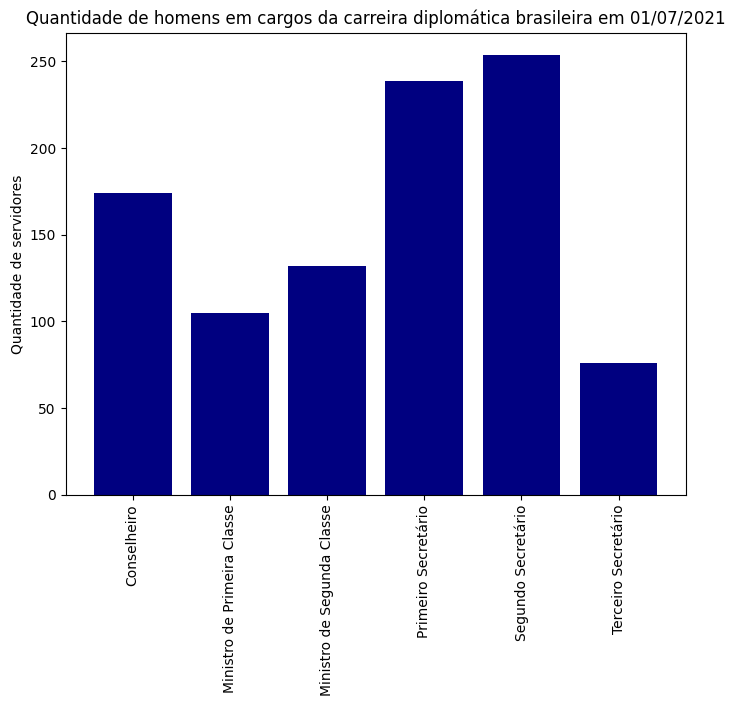

In [ ]:
import matplotlib.pyplot as plt

a = frequencias_ano_7_masc.keys()
b = frequencias_ano_7_masc.values()

plt.figure(figsize=(8,6))
plt.bar(a,b, color="#000080")
plt.ylabel("Quantidade de servidores")
plt.title("Quantidade de homens em cargos da carreira diplomática brasileira em 01/07/2021")
plt.xticks(rotation=90)
plt.show()

## Análise 2022

### Mulheres 2022

In [ ]:
cont_ano_8_fem = df_customizado[(df["Ano"] == 2022) & (df["Sexo"] == "FEM")].value_counts()
cont_ano_8_fem


,count
Cargo,
Primeiro Secretário,85
Segundo Secretário,83
Conselheiro,51
Ministro de Segunda Classe,31
Terceiro Secretário,30
Ministro de Primeira Classe,24
Conselheiro do Quadro Especial,16
Ministro de Primeira Classe do Quadro Especial,13
Ministro de Segunda Classe do Quadro Especial,13


In [ ]:

ano_8_fem = df_customizado[(df["Ano"] == 2022) & (df["Sexo"] == "FEM")]
ano_8_fem


,Cargo
9783,Conselheiro
9784,Conselheiro
9785,Conselheiro
9786,Conselheiro
9787,Conselheiro
...,...
11197,Terceiro Secretário
11198,Terceiro Secretário
11199,Terceiro Secretário
11200,Terceiro Secretário


In [ ]:
from collections import Counter
cargo_termos = ["Terceiro Secretário", "Primeiro Secretário", "Segundo Secretário", "Conselheiro", "Ministro de Segunda Classe", "Ministro de Primeira Classe"]

def contar_cargos(cargo,cargo_termos):

  contador = Counter()
  for palavra in cargo_termos:
    contador[palavra] = (cargo.lower() == (palavra.lower()))
  return contador

## aplicar/chamar a função contar_palavras a coluna de paragrafos e somar as ocorrências
## [lista_paragrafo01, lista_paragrafo02, lista_paragrafo03]
frequencias_ano_8_fem = Counter()
for cargo in ano_8_fem['Cargo']:
  frequencias_ano_8_fem += contar_cargos(cargo,cargo_termos) ## chamando a função contar_palavras e tendo como retorno a contagem dos termos listados

frequencias_ano_8_fem

Counter({'Conselheiro': 51,
         'Ministro de Primeira Classe': 24,
         'Ministro de Segunda Classe': 31,
         'Primeiro Secretário': 85,
         'Segundo Secretário': 83,
         'Terceiro Secretário': 30})

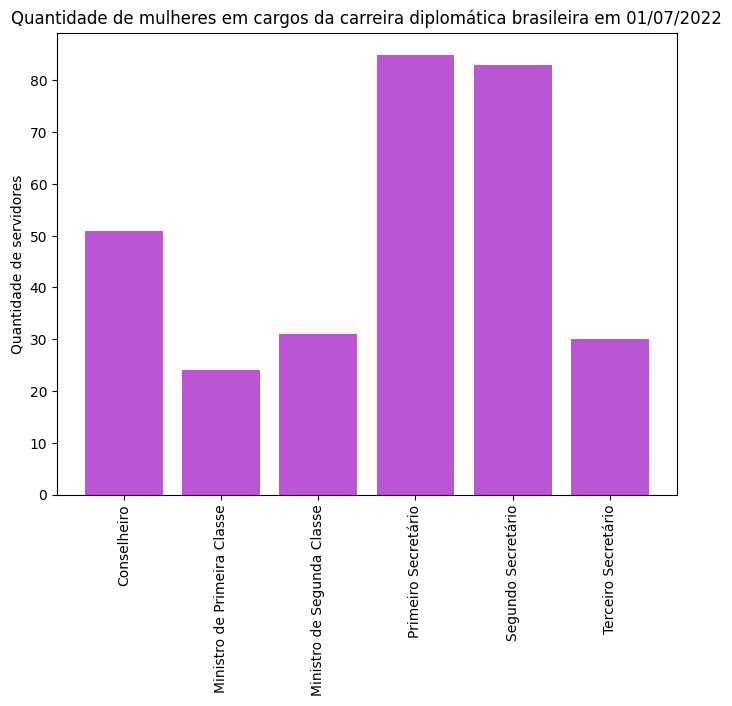

In [ ]:
import matplotlib.pyplot as plt

a = frequencias_ano_8_fem.keys()
b = frequencias_ano_8_fem.values()

plt.figure(figsize=(8,6))
plt.bar(a,b, color="#BA55D3")
plt.ylabel("Quantidade de servidores")
plt.title("Quantidade de mulheres em cargos da carreira diplomática brasileira em 01/07/2022")
plt.xticks(rotation=90)
plt.show()

### Homens 2022

In [ ]:
cont_ano_8_masc = df_customizado[(df["Ano"] == 2022) & (df["Sexo"] == "MASC")].value_counts()
cont_ano_8_masc

,count
Cargo,
Segundo Secretário,252
Primeiro Secretário,240
Conselheiro,171
Ministro de Segunda Classe,137
Ministro de Primeira Classe,104
Terceiro Secretário,84
Conselheiro do Quadro Especial,66
Ministro de Primeira Classe do Quadro Especial,54
Ministro de Segunda Classe do Quadro Especial,46


In [ ]:
ano_8_masc = df_customizado[(df["Ano"] == 2022) & (df["Sexo"] == "MASC")]
ano_8_masc

,Cargo
9834,Conselheiro
9835,Conselheiro
9836,Conselheiro
9837,Conselheiro
9838,Conselheiro
...,...
11281,Terceiro Secretário
11282,Terceiro Secretário
11283,Terceiro Secretário
11284,Terceiro Secretário


In [ ]:
from collections import Counter
cargo_termos = ["Terceiro Secretário", "Primeiro Secretário", "Segundo Secretário", "Conselheiro", "Ministro de Segunda Classe", "Ministro de Primeira Classe"]

def contar_cargos(cargo,cargo_termos):

  contador = Counter()
  for palavra in cargo_termos:
    contador[palavra] = (cargo.lower() == (palavra.lower()))
  return contador

## aplicar/chamar a função contar_palavras a coluna de paragrafos e somar as ocorrências
## [lista_paragrafo01, lista_paragrafo02, lista_paragrafo03]
frequencias_ano_8_masc = Counter()
for cargo in ano_8_masc['Cargo']:
  frequencias_ano_8_masc += contar_cargos(cargo,cargo_termos) ## chamando a função contar_palavras e tendo como retorno a contagem dos termos listados

frequencias_ano_8_masc

Counter({'Conselheiro': 171,
         'Ministro de Primeira Classe': 104,
         'Ministro de Segunda Classe': 137,
         'Primeiro Secretário': 240,
         'Segundo Secretário': 252,
         'Terceiro Secretário': 84})

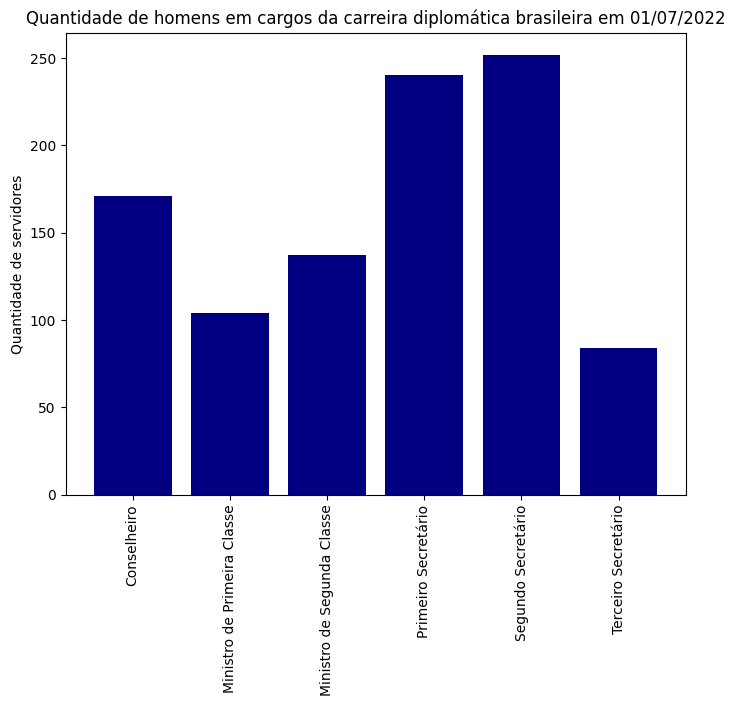

In [ ]:

import matplotlib.pyplot as plt

a = frequencias_ano_8_masc.keys()
b = frequencias_ano_8_masc.values()

plt.figure(figsize=(8,6))
plt.bar(a,b, color="#000080")
plt.ylabel("Quantidade de servidores")
plt.title("Quantidade de homens em cargos da carreira diplomática brasileira em 01/07/2022")
plt.xticks(rotation=90)
plt.show()

## Análise 2023

### Mulheres 2023

In [ ]:
cont_ano_9_fem = df_customizado[(df["Ano"] == 2023) & (df["Sexo"] == "FEM")].value_counts()
cont_ano_9_fem

,count
Cargo,
Primeiro Secretário,86
Segundo Secretário,76
Conselheiro,54
Ministro de Segunda Classe,31
Ministro de Primeira Classe,26
Terceiro Secretário,22
Conselheiro do Quadro Especial,20
Ministro de Primeira Classe do Quadro Especial,16
Ministro de Segunda Classe do Quadro Especial,16


In [ ]:
ano_9_fem = df_customizado[(df["Ano"] == 2023) & (df["Sexo"] == "FEM")]
ano_9_fem

,Cargo
11286,Conselheiro
11287,Conselheiro
11288,Conselheiro
11289,Conselheiro
11290,Conselheiro
...,...
12742,Terceiro Secretário
12743,Terceiro Secretário
12744,Terceiro Secretário
12745,Terceiro Secretário


In [ ]:
from collections import Counter
cargo_termos = ["Terceiro Secretário", "Primeiro Secretário", "Segundo Secretário", "Conselheiro", "Ministro de Segunda Classe", "Ministro de Primeira Classe"]

def contar_cargos(cargo,cargo_termos):

  contador = Counter()
  for palavra in cargo_termos:
    contador[palavra] = (cargo.lower() == (palavra.lower()))
  return contador

## aplicar/chamar a função contar_palavras a coluna de paragrafos e somar as ocorrências
## [lista_paragrafo01, lista_paragrafo02, lista_paragrafo03]
frequencias_ano_9_fem = Counter()
for cargo in ano_9_fem['Cargo']:
  frequencias_ano_9_fem += contar_cargos(cargo,cargo_termos) ## chamando a função contar_palavras e tendo como retorno a contagem dos termos listados

frequencias_ano_9_fem

Counter({'Conselheiro': 54,
         'Ministro de Primeira Classe': 26,
         'Ministro de Segunda Classe': 31,
         'Primeiro Secretário': 86,
         'Segundo Secretário': 76,
         'Terceiro Secretário': 22})

In [ ]:
from collections import Counter
cargo_termos_especial = ["Conselheiro do Quadro Especial", "Ministro de Primeira Classe do Quadro Especial", "Ministro de Segunda Classe do Quadro Especial"]

def contar_cargos(cargo,cargo_termos_especial):

  contador = Counter()
  for palavra in cargo_termos_especial:
    contador[palavra] = (cargo.lower() == (palavra.lower()))
  return contador

## aplicar/chamar a função contar_palavras a coluna de paragrafos e somar as ocorrências
## [lista_paragrafo01, lista_paragrafo02, lista_paragrafo03]
frequencias_ano_9_fem_especial = Counter()
for cargo in ano_9_fem['Cargo']:
  frequencias_ano_9_fem_especial += contar_cargos(cargo,cargo_termos_especial) ## chamando a função contar_palavras e tendo como retorno a contagem dos termos listados

frequencias_ano_9_fem_especial

Counter({'Conselheiro do Quadro Especial': 20,
         'Ministro de Primeira Classe do Quadro Especial': 16,
         'Ministro de Segunda Classe do Quadro Especial': 16})

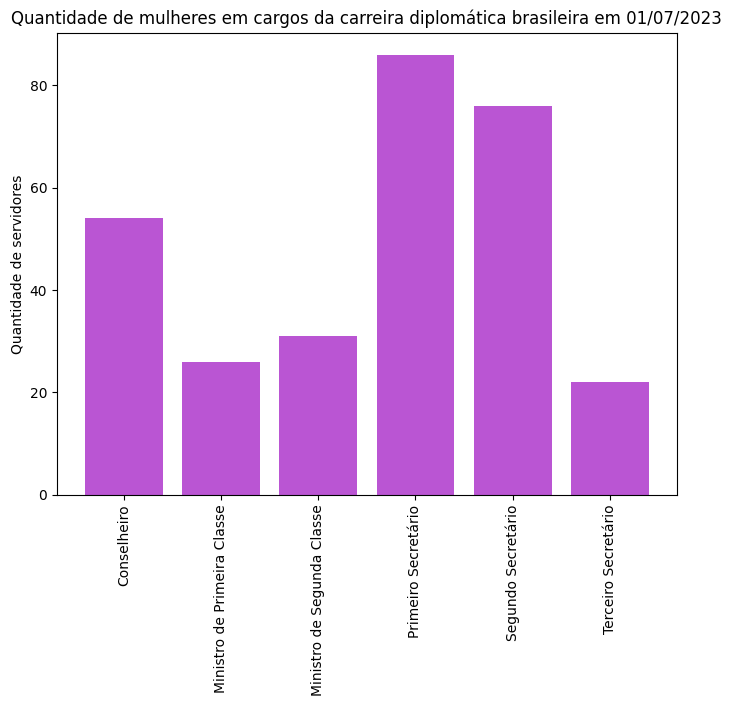

In [ ]:

import matplotlib.pyplot as plt

a = frequencias_ano_9_fem.keys()
b = frequencias_ano_9_fem.values()

plt.figure(figsize=(8,6))
plt.bar(a,b, color="#BA55D3")
plt.ylabel("Quantidade de servidores")
plt.title("Quantidade de mulheres em cargos da carreira diplomática brasileira em 01/07/2023")
plt.xticks(rotation=90)
plt.show()

### Homens 2023

In [ ]:
cont_ano_9_masc = df_customizado[(df["Ano"] == 2023) & (df["Sexo"] == "MASC")].value_counts()
cont_ano_9_masc

,count
Cargo,
Segundo Secretário,259
Primeiro Secretário,251
Conselheiro,163
Ministro de Segunda Classe,135
Ministro de Primeira Classe,103
Conselheiro do Quadro Especial,75
Ministro de Primeira Classe do Quadro Especial,68
Ministro de Segunda Classe do Quadro Especial,57
Terceiro Secretário,44


In [ ]:
ano_9_masc = df_customizado[(df["Ano"] == 2023) & (df["Sexo"] == "MASC")]
ano_9_masc

,Cargo
11340,Conselheiro
11341,Conselheiro
11342,Conselheiro
11343,Conselheiro
11344,Conselheiro
...,...
12786,Terceiro Secretário
12787,Terceiro Secretário
12788,Terceiro Secretário
12789,Terceiro Secretário


In [ ]:
from collections import Counter
cargo_termos = ["Terceiro Secretário", "Primeiro Secretário", "Segundo Secretário", "Conselheiro", "Ministro de Segunda Classe", "Ministro de Primeira Classe"]

def contar_cargos(cargo,cargo_termos):

  contador = Counter()
  for palavra in cargo_termos:
    contador[palavra] = (cargo.lower() == (palavra.lower()))
  return contador

## aplicar/chamar a função contar_palavras a coluna de paragrafos e somar as ocorrências
## [lista_paragrafo01, lista_paragrafo02, lista_paragrafo03]
frequencias_ano_9_masc = Counter()
for cargo in ano_9_masc['Cargo']:
  frequencias_ano_9_masc += contar_cargos(cargo,cargo_termos) ## chamando a função contar_palavras e tendo como retorno a contagem dos termos listados

frequencias_ano_9_masc

Counter({'Conselheiro': 163,
         'Ministro de Primeira Classe': 103,
         'Ministro de Segunda Classe': 135,
         'Primeiro Secretário': 251,
         'Segundo Secretário': 259,
         'Terceiro Secretário': 44})

In [ ]:
from collections import Counter
cargo_termos_especial = ["Conselheiro do Quadro Especial", "Ministro de Primeira Classe do Quadro Especial", "Ministro de Segunda Classe do Quadro Especial"]

def contar_cargos(cargo,cargo_termos_especial):

  contador = Counter()
  for palavra in cargo_termos_especial:
    contador[palavra] = (cargo.lower() == (palavra.lower()))
  return contador

## aplicar/chamar a função contar_palavras a coluna de paragrafos e somar as ocorrências
## [lista_paragrafo01, lista_paragrafo02, lista_paragrafo03]
frequencias_ano_9_masc_especial = Counter()
for cargo in ano_9_masc['Cargo']:
  frequencias_ano_9_masc_especial += contar_cargos(cargo,cargo_termos_especial) ## chamando a função contar_palavras e tendo como retorno a contagem dos termos listados

frequencias_ano_9_masc_especial

Counter({'Conselheiro do Quadro Especial': 75,
         'Ministro de Primeira Classe do Quadro Especial': 68,
         'Ministro de Segunda Classe do Quadro Especial': 57})

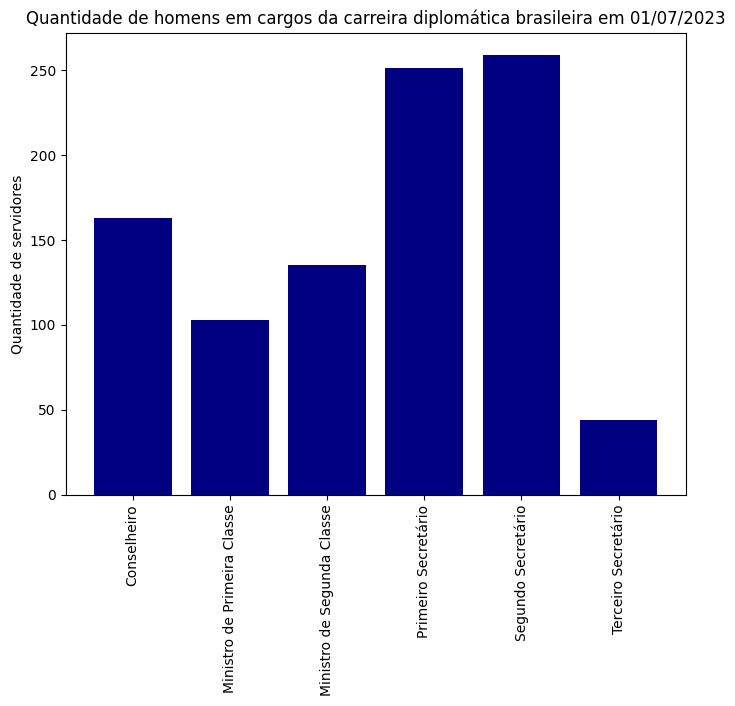

In [ ]:
import matplotlib.pyplot as plt

a = frequencias_ano_9_masc.keys()
b = frequencias_ano_9_masc.values()

plt.figure(figsize=(8,6))
plt.bar(a,b, color="#000080")
plt.ylabel("Quantidade de servidores")
plt.title("Quantidade de homens em cargos da carreira diplomática brasileira em 01/07/2023")
plt.xticks(rotation=90)
plt.show()

# Análise comparativa de 2015 e 2023

- Verificar como viabilizar essa análise

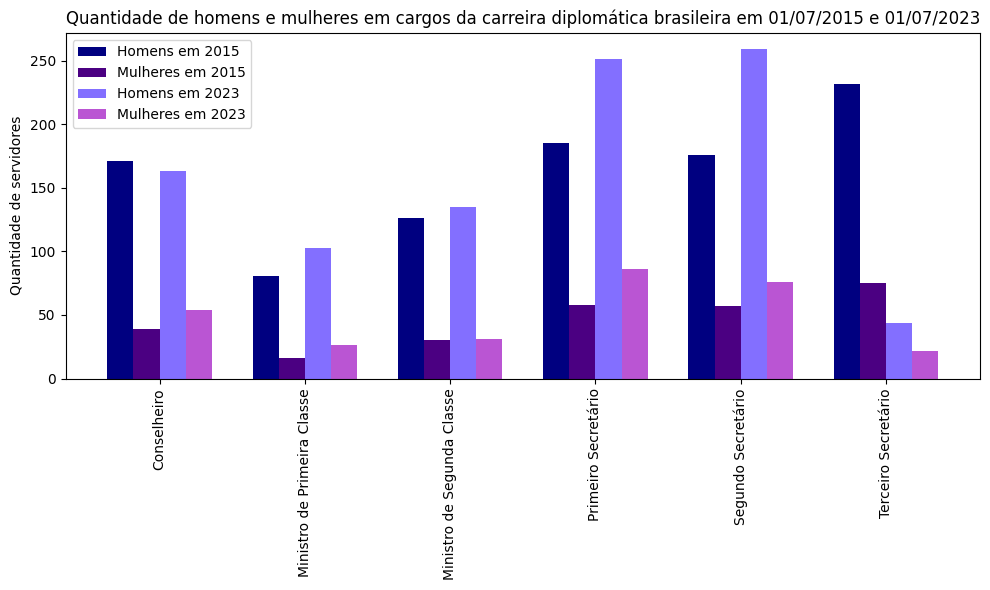

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


cargos = list(frequencias_ano_1_fem.keys())
x = np.arange(len(cargos))
largura = 0.18

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - 1.5 * largura, frequencias_ano_1_masc.values(), largura, label='Homens em 2015 ', color="#000080")
ax.bar(x - 0.5 * largura, frequencias_ano_1_fem.values(), largura, label='Mulheres em 2015', color="#4B0082")
ax.bar(x + 0.5 * largura, frequencias_ano_9_masc.values(), largura, label='Homens em 2023', color="#836FFF")
ax.bar(x + 1.5 * largura, frequencias_ano_9_fem.values(), largura, label='Mulheres em 2023', color="#BA55D3")

ax.set_ylabel('Quantidade de servidores')
ax.set_title('Quantidade de homens e mulheres em cargos da carreira diplomática brasileira em 01/07/2015 e 01/07/2023')
ax.set_xticks(x)
ax.set_xticklabels(cargos, rotation=90)
ax.legend()
plt.tight_layout()
plt.show()


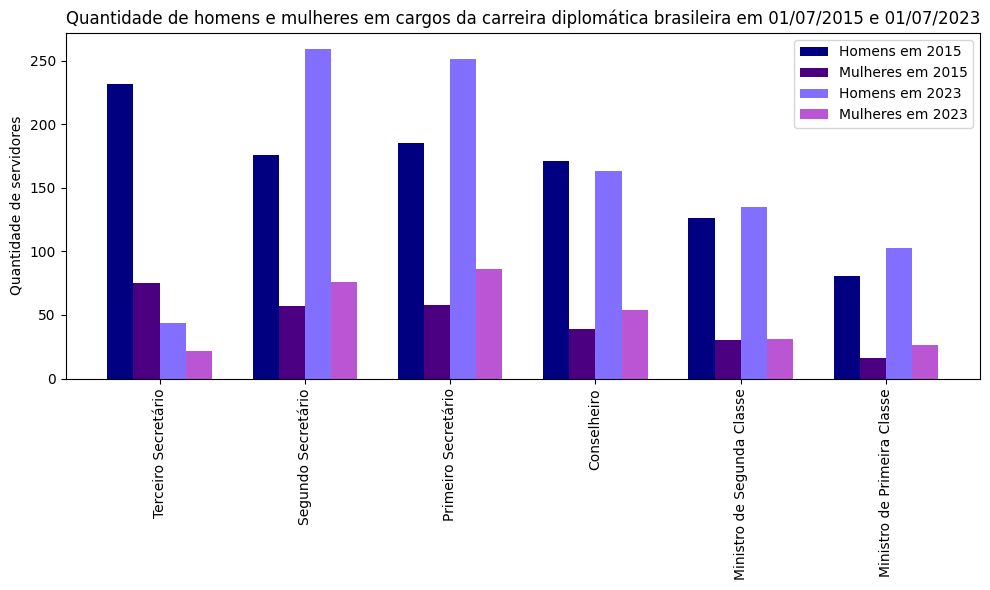

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


ordem_desejada = [
    "Terceiro Secretário",
    "Segundo Secretário",
    "Primeiro Secretário",
    "Conselheiro",
    "Ministro de Segunda Classe",
    "Ministro de Primeira Classe"
]


masc_2015 = [frequencias_ano_1_masc[cargo] for cargo in ordem_desejada]
fem_2015  = [frequencias_ano_1_fem[cargo]  for cargo in ordem_desejada]
masc_2023 = [frequencias_ano_9_masc[cargo] for cargo in ordem_desejada]
fem_2023  = [frequencias_ano_9_fem[cargo]  for cargo in ordem_desejada]


x = np.arange(len(ordem_desejada))
largura = 0.18


fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - 1.5 * largura, masc_2015, largura, label='Homens em 2015', color="#000080")
ax.bar(x - 0.5 * largura, fem_2015,  largura, label='Mulheres em 2015', color="#4B0082")
ax.bar(x + 0.5 * largura, masc_2023, largura, label='Homens em 2023', color="#836FFF")
ax.bar(x + 1.5 * largura, fem_2023,  largura, label='Mulheres em 2023', color="#BA55D3")

ax.set_ylabel('Quantidade de servidores')
ax.set_title('Quantidade de homens e mulheres em cargos da carreira diplomática brasileira em 01/07/2015 e 01/07/2023')
ax.set_xticks(x)
ax.set_xticklabels(ordem_desejada, rotation=90)
ax.legend()

plt.tight_layout()
plt.show()


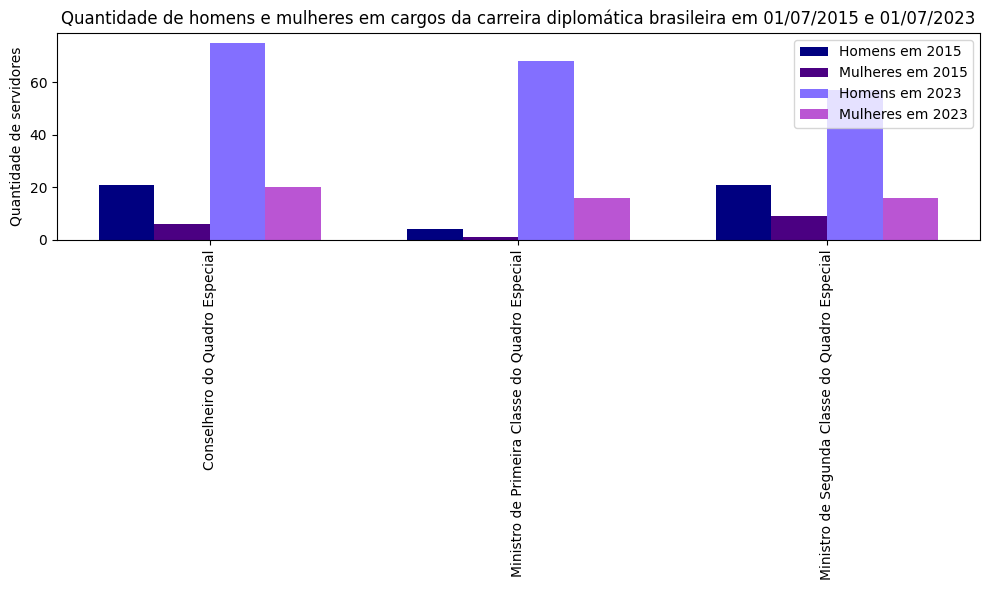

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


ordem_desejada = [
   "Conselheiro do Quadro Especial",
   "Ministro de Primeira Classe do Quadro Especial",
   "Ministro de Segunda Classe do Quadro Especial"
]


masc_2015 = [frequencias_ano_1_masc_especial[cargo] for cargo in ordem_desejada]
fem_2015  = [frequencias_ano_1_fem_especial[cargo]  for cargo in ordem_desejada]
masc_2023 = [frequencias_ano_9_masc_especial[cargo] for cargo in ordem_desejada]
fem_2023  = [frequencias_ano_9_fem_especial[cargo]  for cargo in ordem_desejada]


x = np.arange(len(ordem_desejada))
largura = 0.18


fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - 1.5 * largura, masc_2015, largura, label='Homens em 2015', color="#000080")
ax.bar(x - 0.5 * largura, fem_2015,  largura, label='Mulheres em 2015', color="#4B0082")
ax.bar(x + 0.5 * largura, masc_2023, largura, label='Homens em 2023', color="#836FFF")
ax.bar(x + 1.5 * largura, fem_2023,  largura, label='Mulheres em 2023', color="#BA55D3")

ax.set_ylabel('Quantidade de servidores')
ax.set_title('Quantidade de homens e mulheres em cargos da carreira diplomática brasileira em 01/07/2015 e 01/07/2023')
ax.set_xticks(x)
ax.set_xticklabels(ordem_desejada, rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

## Gráfico 2015

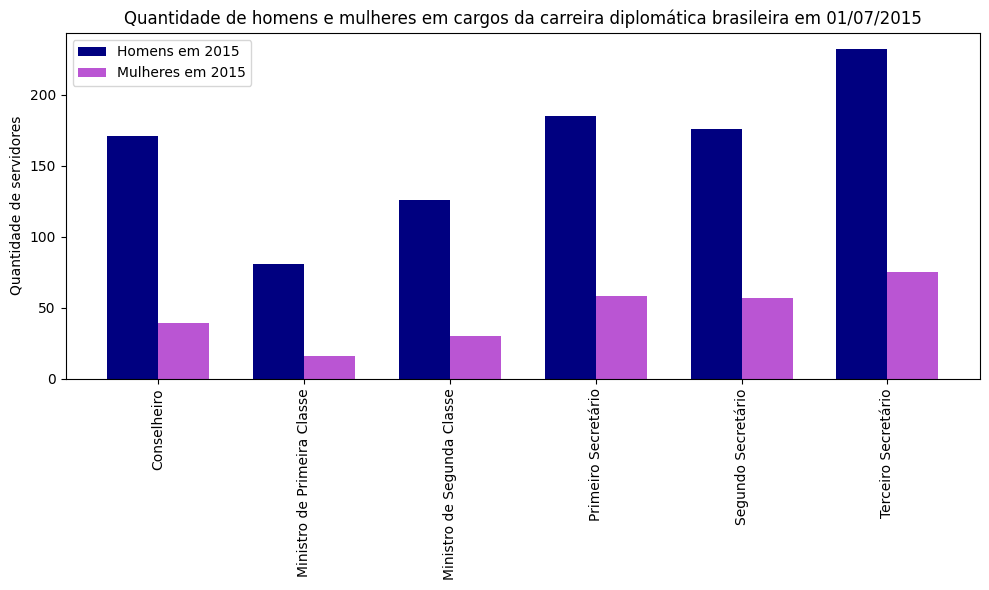

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


cargos = list(frequencias_ano_1_fem.keys())
x = np.arange(len(cargos))
largura = 0.35

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - largura/2, frequencias_ano_1_masc.values(), largura, label='Homens em 2015 ', color="#000080")
ax.bar(x + largura/2, frequencias_ano_1_fem.values(), largura, label='Mulheres em 2015', color="#BA55D3")


ax.set_ylabel('Quantidade de servidores')
ax.set_title('Quantidade de homens e mulheres em cargos da carreira diplomática brasileira em 01/07/2015')
ax.set_xticks(x)
ax.set_xticklabels(cargos, rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

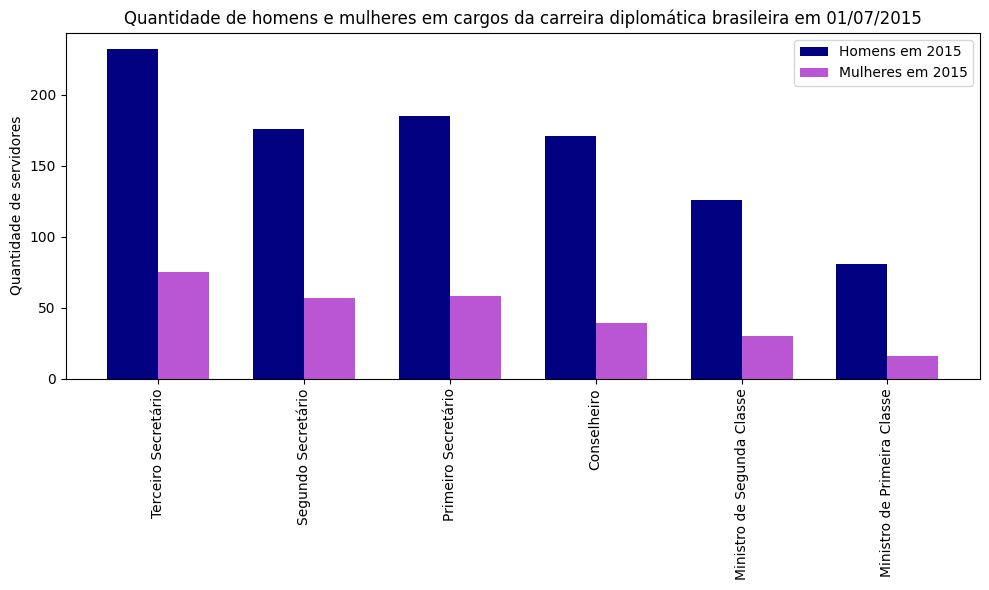

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


ordem_desejada = [
    "Terceiro Secretário",
    "Segundo Secretário",
    "Primeiro Secretário",
    "Conselheiro",
    "Ministro de Segunda Classe",
    "Ministro de Primeira Classe"
]


fem = [frequencias_ano_1_fem[cargo] for cargo in ordem_desejada]
masc = [frequencias_ano_1_masc[cargo] for cargo in ordem_desejada]


x = np.arange(len(ordem_desejada))
largura = 0.35


fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - largura/2, masc, largura, label='Homens em 2015', color="#000080")
ax.bar(x + largura/2, fem, largura, label='Mulheres em 2015', color="#BA55D3")


ax.set_ylabel('Quantidade de servidores')
ax.set_title('Quantidade de homens e mulheres em cargos da carreira diplomática brasileira em 01/07/2015')
ax.set_xticks(x)
ax.set_xticklabels(ordem_desejada, rotation=90)
ax.legend()

plt.tight_layout()
plt.show()


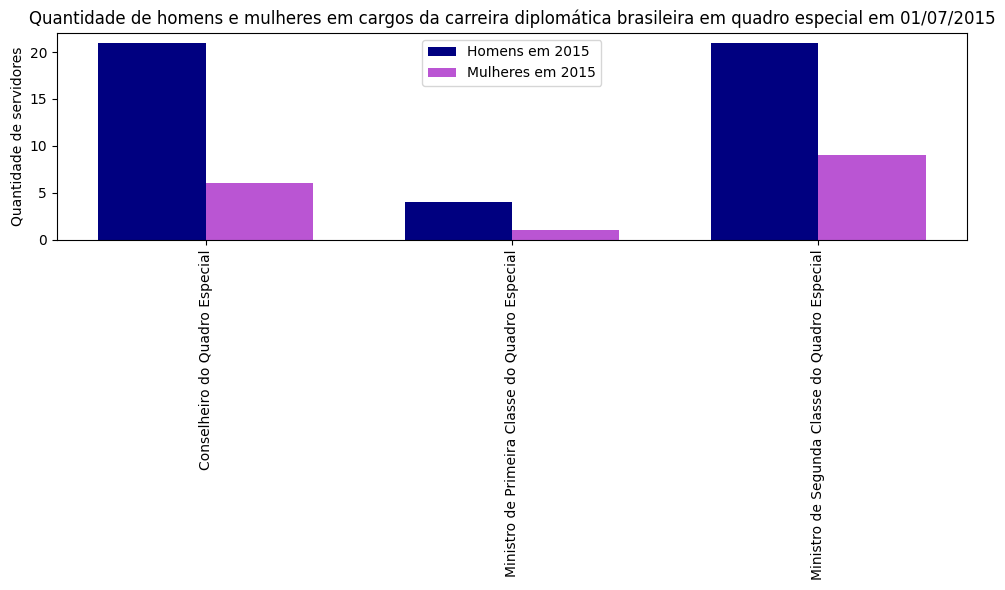

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


ordem_desejada = [
   "Conselheiro do Quadro Especial",
   "Ministro de Primeira Classe do Quadro Especial",
   "Ministro de Segunda Classe do Quadro Especial"
]


fem = [frequencias_ano_1_fem_especial[cargo] for cargo in ordem_desejada]
masc = [frequencias_ano_1_masc_especial[cargo] for cargo in ordem_desejada]


x = np.arange(len(ordem_desejada))
largura = 0.35


fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - largura/2, masc, largura, label='Homens em 2015', color="#000080")
ax.bar(x + largura/2, fem, largura, label='Mulheres em 2015', color="#BA55D3")


ax.set_ylabel('Quantidade de servidores')
ax.set_title('Quantidade de homens e mulheres em cargos da carreira diplomática brasileira em quadro especial em 01/07/2015')
ax.set_xticks(x)
ax.set_xticklabels(ordem_desejada, rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

## Gráfico 2023


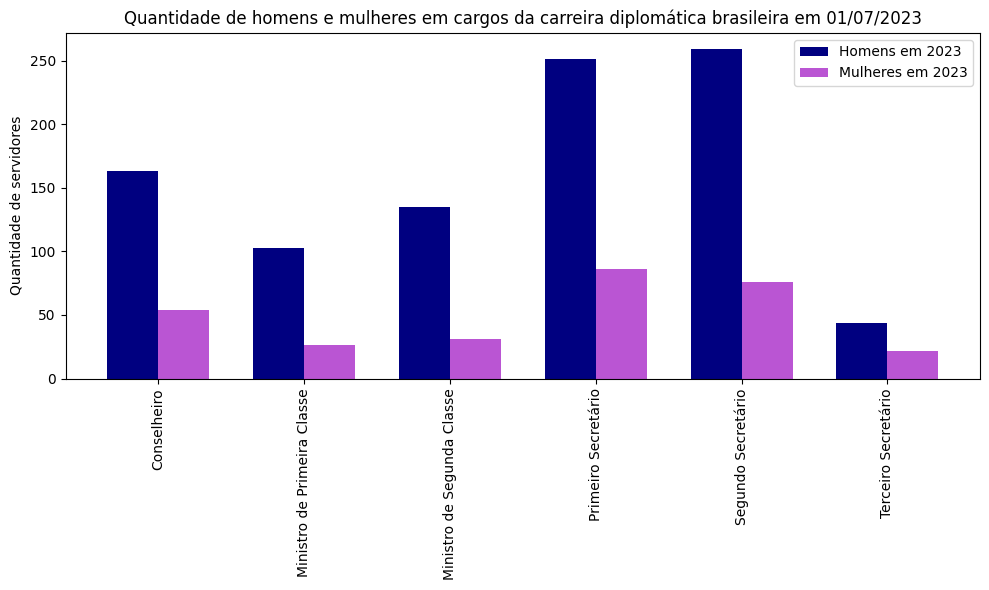

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


cargos = list(frequencias_ano_9_fem.keys())
x = np.arange(len(cargos))
largura = 0.35

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - largura/2, frequencias_ano_9_masc.values(), largura, label='Homens em 2023 ', color="#000080")
ax.bar(x + largura/2, frequencias_ano_9_fem.values(), largura, label='Mulheres em 2023', color="#BA55D3")


ax.set_ylabel('Quantidade de servidores')
ax.set_title('Quantidade de homens e mulheres em cargos da carreira diplomática brasileira em 01/07/2023')
ax.set_xticks(x)
ax.set_xticklabels(cargos, rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

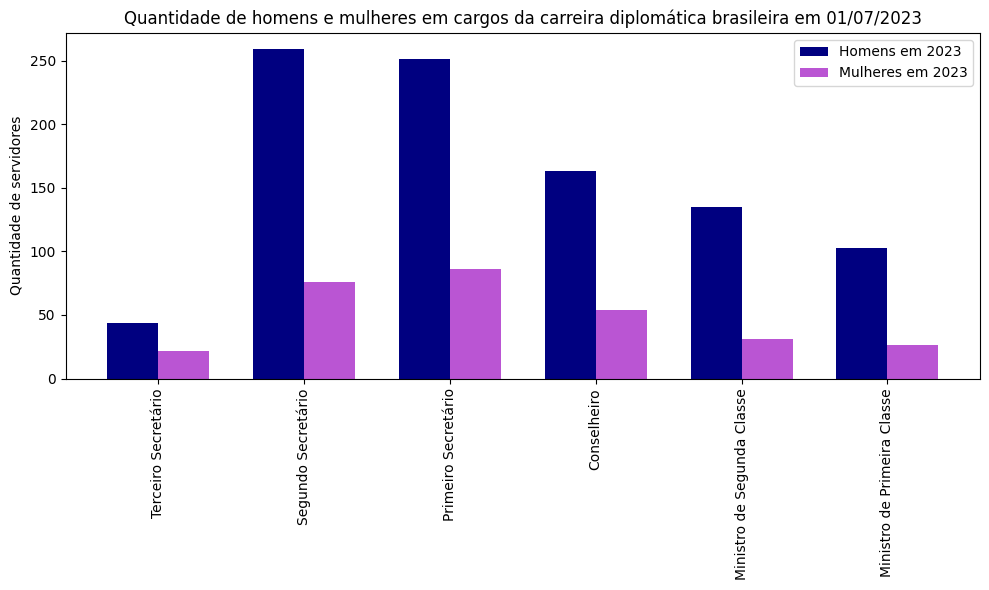

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


ordem_desejada = [
    "Terceiro Secretário",
    "Segundo Secretário",
    "Primeiro Secretário",
    "Conselheiro",
    "Ministro de Segunda Classe",
    "Ministro de Primeira Classe"
]


fem = [frequencias_ano_9_fem[cargo] for cargo in ordem_desejada]
masc = [frequencias_ano_9_masc[cargo] for cargo in ordem_desejada]


x = np.arange(len(ordem_desejada))
largura = 0.35


fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - largura/2, masc, largura, label='Homens em 2023', color="#000080")
ax.bar(x + largura/2, fem, largura, label='Mulheres em 2023', color="#BA55D3")


ax.set_ylabel('Quantidade de servidores')
ax.set_title('Quantidade de homens e mulheres em cargos da carreira diplomática brasileira em 01/07/2023')
ax.set_xticks(x)
ax.set_xticklabels(ordem_desejada, rotation=90)
ax.legend()

plt.tight_layout()
plt.show()


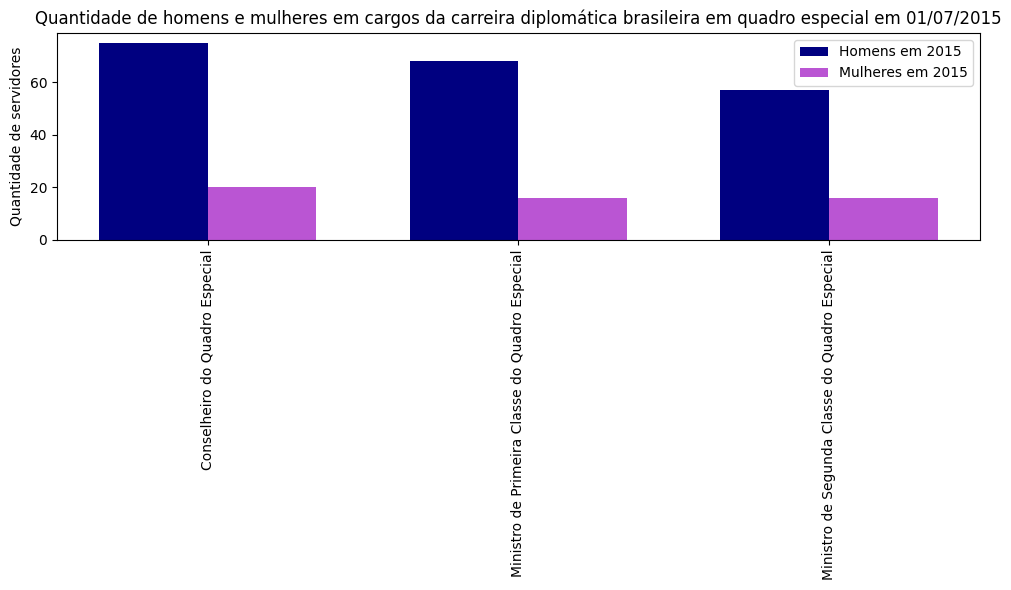

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


ordem_desejada = [
   "Conselheiro do Quadro Especial",
   "Ministro de Primeira Classe do Quadro Especial",
   "Ministro de Segunda Classe do Quadro Especial"
]


fem = [frequencias_ano_9_fem_especial[cargo] for cargo in ordem_desejada]
masc = [frequencias_ano_9_masc_especial[cargo] for cargo in ordem_desejada]


x = np.arange(len(ordem_desejada))
largura = 0.35


fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - largura/2, masc, largura, label='Homens em 2015', color="#000080")
ax.bar(x + largura/2, fem, largura, label='Mulheres em 2015', color="#BA55D3")


ax.set_ylabel('Quantidade de servidores')
ax.set_title('Quantidade de homens e mulheres em cargos da carreira diplomática brasileira em quadro especial em 01/07/2015')
ax.set_xticks(x)
ax.set_xticklabels(ordem_desejada, rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

# Tabela

## Tabela 2015


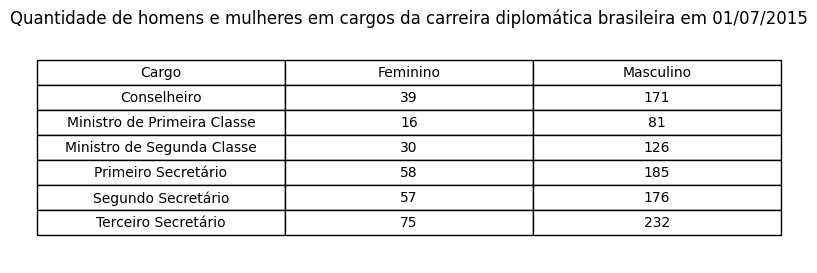

In [ ]:
import pandas as pd


df_fem = pd.DataFrame(frequencias_ano_1_fem.items(), columns=["Cargo", "Feminino"])
df_masc = pd.DataFrame(frequencias_ano_1_masc.items(), columns=["Cargo", "Masculino"])

# Juntar pela coluna "Cargo"
df_total = pd.merge(df_fem, df_masc, on="Cargo", how="outer").fillna(0)
df_total

# Criar figura
fig, ax = plt.subplots(figsize=(8, 3))  # Ajuste o tamanho conforme necessário
ax.axis('off')  # Remove os eixos

tabela = ax.table(
    cellText=df_total.values,
    colLabels=df_total.columns,
    cellLoc='center',
    loc='center'
)


tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.5)
plt.title('Quantidade de homens e mulheres em cargos da carreira diplomática brasileira em 01/07/2015')
# Salva como imagem PNG
plt.savefig("tabela_frequencia.png", bbox_inches='tight', dpi=300)


plt.show()

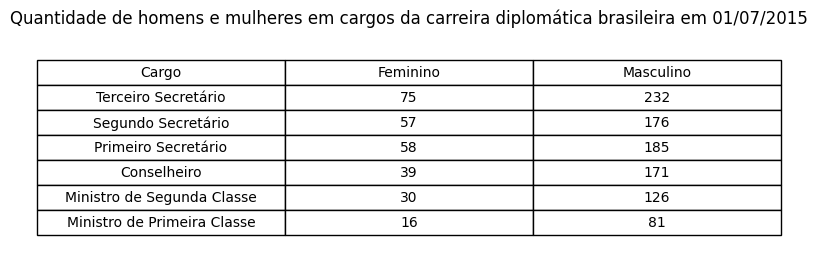

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ordem desejada dos cargos
ordem_desejada = [
    "Terceiro Secretário",
    "Segundo Secretário",
    "Primeiro Secretário",
    "Conselheiro",
    "Ministro de Segunda Classe",
    "Ministro de Primeira Classe"
]

# Criando os DataFrames
df_fem = pd.DataFrame(frequencias_ano_1_fem.items(), columns=["Cargo", "Feminino"])
df_masc = pd.DataFrame(frequencias_ano_1_masc.items(), columns=["Cargo", "Masculino"])

# Juntando os dados
df_total = pd.merge(df_fem, df_masc, on="Cargo", how="outer").fillna(0)

# Reordenando com base na ordem desejada
df_total["Cargo"] = pd.Categorical(df_total["Cargo"], categories=ordem_desejada, ordered=True)
df_total = df_total.sort_values("Cargo")

# Criando figura
fig, ax = plt.subplots(figsize=(8, 3))  # Ajuste o tamanho conforme necessário
ax.axis('off')  # Remove os eixos

# Adicionando a tabela
tabela = ax.table(
    cellText=df_total.values,
    colLabels=df_total.columns,
    cellLoc='center',
    loc='center'
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.5)

plt.title('Quantidade de homens e mulheres em cargos da carreira diplomática brasileira em 01/07/2015')

# Salva como imagem PNG
plt.savefig("tabela_frequencia_2015.png", bbox_inches='tight', dpi=300)

plt.show()


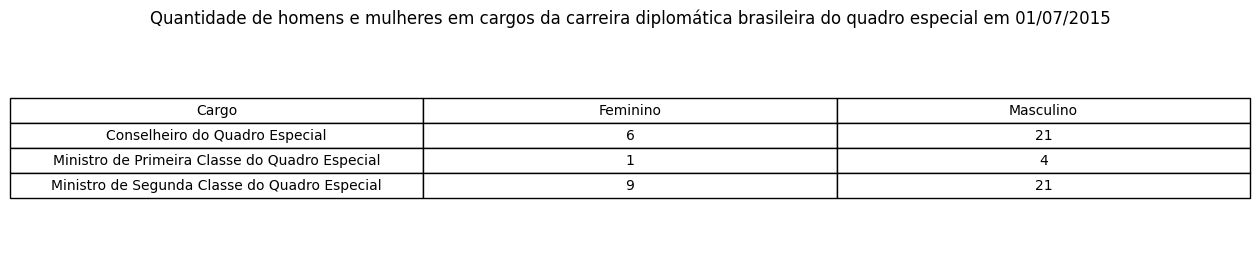

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ordem desejada dos cargos
ordem_desejada = [
   "Conselheiro do Quadro Especial",
   "Ministro de Primeira Classe do Quadro Especial",
   "Ministro de Segunda Classe do Quadro Especial"
]

# Criando os DataFrames
df_fem = pd.DataFrame(frequencias_ano_1_fem_especial.items(), columns=["Cargo", "Feminino"])
df_masc = pd.DataFrame(frequencias_ano_1_masc_especial.items(), columns=["Cargo", "Masculino"])

# Juntando os dados
df_total = pd.merge(df_fem, df_masc, on="Cargo", how="outer").fillna(0)

# Reordenando com base na ordem desejada
df_total["Cargo"] = pd.Categorical(df_total["Cargo"], categories=ordem_desejada, ordered=True)
df_total = df_total.sort_values("Cargo")

# Criando figura
fig, ax = plt.subplots(figsize=(8, 3))  # Ajuste o tamanho conforme necessário
ax.axis('off')  # Remove os eixos

# Adicionando a tabela
tabela = ax.table(
    cellText=df_total.values,
    colLabels=df_total.columns,
    cellLoc='center',
    loc='center'
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(2, 1.5)

plt.title('Quantidade de homens e mulheres em cargos da carreira diplomática brasileira do quadro especial em 01/07/2015')

# Salva como imagem PNG
plt.savefig("tabela_frequencia_2015.png", bbox_inches='tight', dpi=300)

plt.show()

## Tabela 2023

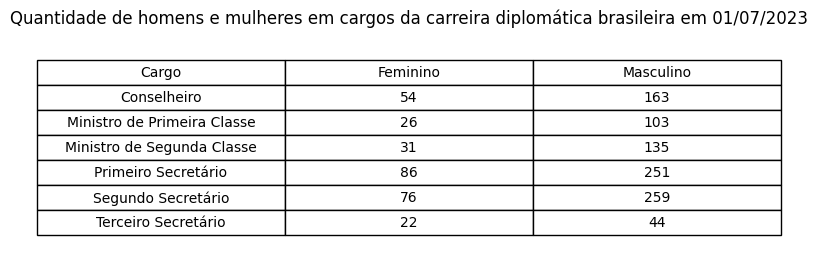

In [ ]:
import pandas as pd


df_fem = pd.DataFrame(frequencias_ano_9_fem.items(), columns=["Cargo", "Feminino"])
df_masc = pd.DataFrame(frequencias_ano_9_masc.items(), columns=["Cargo", "Masculino"])

# Juntar pela coluna "Cargo"
df_total = pd.merge(df_fem, df_masc, on="Cargo", how="outer").fillna(0)
df_total

# Criar figura
fig, ax = plt.subplots(figsize=(8, 3))  # Ajuste o tamanho conforme necessário
ax.axis('off')  # Remove os eixos

tabela = ax.table(
    cellText=df_total.values,
    colLabels=df_total.columns,
    cellLoc='center',
    loc='center'
)


tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.5)
plt.title('Quantidade de homens e mulheres em cargos da carreira diplomática brasileira em 01/07/2023')
# Salva como imagem PNG
plt.savefig("tabela_frequencia.png", bbox_inches='tight', dpi=300)


plt.show()

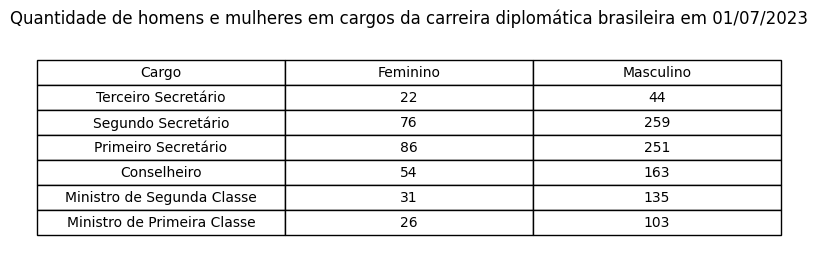

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ordem desejada dos cargos
ordem_desejada = [
    "Terceiro Secretário",
    "Segundo Secretário",
    "Primeiro Secretário",
    "Conselheiro",
    "Ministro de Segunda Classe",
    "Ministro de Primeira Classe"
]

# Criando os DataFrames
df_fem = pd.DataFrame(frequencias_ano_9_fem.items(), columns=["Cargo", "Feminino"])
df_masc = pd.DataFrame(frequencias_ano_9_masc.items(), columns=["Cargo", "Masculino"])

# Juntando os dados
df_total = pd.merge(df_fem, df_masc, on="Cargo", how="outer").fillna(0)

# Reordenando com base na ordem desejada
df_total["Cargo"] = pd.Categorical(df_total["Cargo"], categories=ordem_desejada, ordered=True)
df_total = df_total.sort_values("Cargo")

# Criando figura
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')  # Remove os eixos

# Adicionando a tabela
tabela = ax.table(
    cellText=df_total.values,
    colLabels=df_total.columns,
    cellLoc='center',
    loc='center'
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.5)

# Título e salvamento
plt.title('Quantidade de homens e mulheres em cargos da carreira diplomática brasileira em 01/07/2023')
plt.savefig("tabela_frequencia.png", bbox_inches='tight', dpi=300)
plt.show()


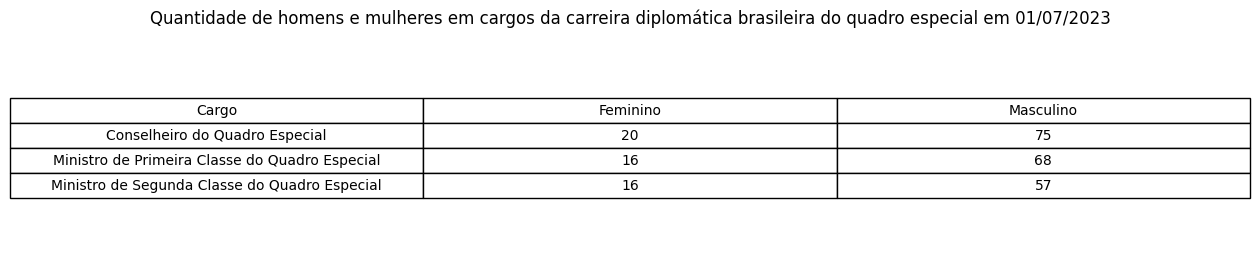

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ordem desejada dos cargos
ordem_desejada = [
   "Conselheiro do Quadro Especial",
   "Ministro de Primeira Classe do Quadro Especial",
   "Ministro de Segunda Classe do Quadro Especial"
]

# Criando os DataFrames
df_fem = pd.DataFrame(frequencias_ano_9_fem_especial.items(), columns=["Cargo", "Feminino"])
df_masc = pd.DataFrame(frequencias_ano_9_masc_especial.items(), columns=["Cargo", "Masculino"])

# Juntando os dados
df_total = pd.merge(df_fem, df_masc, on="Cargo", how="outer").fillna(0)

# Reordenando com base na ordem desejada
df_total["Cargo"] = pd.Categorical(df_total["Cargo"], categories=ordem_desejada, ordered=True)
df_total = df_total.sort_values("Cargo")

# Criando figura
fig, ax = plt.subplots(figsize=(8, 3))  # Ajuste o tamanho conforme necessário
ax.axis('off')  # Remove os eixos

# Adicionando a tabela
tabela = ax.table(
    cellText=df_total.values,
    colLabels=df_total.columns,
    cellLoc='center',
    loc='center'
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(2, 1.5)

plt.title('Quantidade de homens e mulheres em cargos da carreira diplomática brasileira do quadro especial em 01/07/2023')

# Salva como imagem PNG
plt.savefig("tabela_frequencia_2015.png", bbox_inches='tight', dpi=300)

plt.show()